# Script B - Texas: 2026 House Election
Mapping Democracy: Quantifying Ethnolinguistic Gerrymandering Through the Lens of the Modifiable Areal Unit Problem

Kuba Kowalski - 1012340 - 15/01/2026


Thesis Report GIRS-2025-71, Thesis code number: GRS-80436

Supervisor: Dr. Jennifer Koch

## Description of Notebook
This notebook consists of 4 sections:
- Section 1 sets the global environment and creates the intermediate datasets.
- Section 2 runs the simulation for the 2026 Texas Midterms using proxy data.
- Section 3 creates the main visualizations for the results chapter of the thesis report.
- Section 4 creates the secondary visualizations for other chapters of the thesis report. 

Each section starts by setting the input and outputs paths, and imports the necessary packages. 

Runtime is roughly 1.5h with following hardware: 
- CPU: Intel Core i9-14900KF
- RAM: 64 GB (Corsair Vengeance DDR5 32x2)
- GPU: NVIDIA GeForce RTX 4080 Super


## 1. Aggregation

The purpose of the cells below is to import the necessary packages, set the paths for inputs and outputs, and define the functions used to create the intermediate dataset that aggregates demographic and election outcome data on the level of voting tabulation districts.

In [1]:
# Packages

import sys
import re
import numpy as np
import pandas as pd
import pyogrio # Used for read because gpd clashes with one input dataset for an unknown reason
import geopandas as gpd
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as mcm
import ipywidgets as widgets
import math

from collections import defaultdict
from statistics import stdev
from pathlib import Path
from IPython.display import display, clear_output
from functools import partial
from gerrychain import Graph, Partition, updaters, accept, MarkovChain
from gerrychain.proposals import recom
from gerrychain.tree import recursive_tree_part
from gerrychain.constraints import within_percent_of_ideal_population
from gerrychain import Election
from gerrychain.metrics import mean_median, efficiency_gap, partisan_bias
from gerrychain import Graph, Partition
from gerrychain.updaters import Election, Tally, cut_edges

In [2]:
# Paths

## Inputs
VTD_FP    = r"./inputs/TX/tl_2020_48_vtd20/tl_2020_48_vtd20.shp"        
VEST_FP   = r"./inputs/TX/tx_vest_20/tx_vest_20.shp"                    
BLOCKS_SRC = r"./inputs/TX/nhgis0005_shape/TX_block_2020.shp"           
NHGIS_CSV  = r"./inputs/TX/nhgis0004_csv/nhgis0004_ds258_2020_block.csv"              
CD116_FP  = r"./inputs/TX/tx_cong_adopted_2025/PLANC2333/PLANC2333.shp" # District tag for 2026 scenario

## Intermediate
BLOCKS_FP = r"./intermediate/TX/nhgis_tx_block_2020_withpop.gpkg" 
OUT_GPKG   = r"./intermediate/TX/nhgis_tx_block_2020_withpop.gpkg"
OUT_LAYER  = "blocks"

## Outputs
OUT_GPKG  = "./outputs/TX/TX_vtds_2020_final.gpkg"
OUT_SHP   = "./outputs/TX/TX_vtds_2020_final.shp"
LAYER     = "vtds_2020"

In [3]:
# Functions

## Repairing geometry in input data using buffer method. 
def clean(g):
    g["geometry"] = g.geometry.make_valid().buffer(0)
    g = g.explode(index_parts=False, ignore_index=True)
    g = g[~g.geometry.is_empty].copy()
    return g

## Aggregating population (blocks) and electoral outcomes (precincts) into voting tabulation districts (VTDs) using the area weighting method
def area_weight_allocate(source_gdf, target_gdf, value_cols, source_id_col):
    """Area-weight allocate source value_cols onto targets. Renormalizes per source."""
    
    ## Indexes blocks/precincts and stores area for weighting
    src = source_gdf.reset_index(drop=False).rename(columns={"index":"__src_id"})
    if "__src_area" not in src:
        src["__src_area"] = src.geometry.area

    ## Computes intersection area of blocks/precincts and VTDs
    inter = gpd.overlay(
        src[[source_id_col, "__src_id", "__src_area", *value_cols, "geometry"]],
        target_gdf[["__TARGET_ID__", "geometry"]],
        how="intersection"
    )
    inter["__int_area"] = inter.geometry.area
    inter["__w"] = (inter["__int_area"] / inter["__src_area"]).replace([np.inf, -np.inf], 0).fillna(0).clip(0, 1)

    ## If a block/precinct has no intersection, buffer it slightly to force an overlap with a VTD and calculate intersection area
    hit_src = set(inter["__src_id"])
    missing_src = sorted(set(src["__src_id"]) - hit_src)
    if missing_src:
        miss = src.loc[src["__src_id"].isin(missing_src), [source_id_col, "__src_id","__src_area", *value_cols, "geometry"]].copy() ## miss = blocks/precincts without VTD overlap
        miss["geometry"] = miss.geometry.buffer(2)  # 2 meters in EPSG:5070
        inter2 = gpd.overlay(miss, target_gdf[["__TARGET_ID__", "geometry"]], how="intersection")
        inter2["__int_area"] = inter2.geometry.area
        inter2["__w"] = (inter2["__int_area"] / inter2["__src_area"]).replace([np.inf, -np.inf], 0).fillna(0).clip(0, 1)
        inter = pd.concat([inter, inter2], ignore_index=True) ## Appends new interactions to the results previous part of function

    ## Ensures weights sum to 1.0
    wsum = inter.groupby("__src_id")["__w"].transform("sum").replace(0, np.nan)
    inter["__w_norm"] = (inter["__w"] / wsum).fillna(0).clip(0, 1)

    ## Applies calculated weights to population and voting outcome columns
    for c in value_cols:
        inter[c + "_w"] = pd.to_numeric(inter[c], errors="coerce").fillna(0.0) * inter["__w_norm"]

    ## sSums weighted contributions to each VTD
    agg = inter.groupby("__TARGET_ID__", as_index=False)[[c + "_w" for c in value_cols]].sum()
    return agg.rename(columns={c + "_w": c for c in [*value_cols]})

## Generating initial districting plan for Markov Chain run
def make_seed(graph, k, ideal, pop_col="TOTPOP"):
    def seed(eps):
        return recursive_tree_part(
            graph,
            parts=range(k),
            pop_target=ideal,
            pop_col=pop_col,
            epsilon=eps
        )
    return seed


In [4]:
# --- INPUTS ---
# Use your original NHGIS blocks geometry here (SHP or ZIP), not the (yet-to-be-created) GPKG
BLOCKS_SRC = r"./inputs/TX/nhgis0005_shape/TX_block_2020.shp"      # or "./inputs/TX/nhgis0002_shape.zip"
NHGIS_CSV  = r"./inputs/TX/nhgis0004_csv/nhgis0004_ds258_2020_block.csv"         # e.g., ds258 P1 Total pop table

# --- OUTPUT (will be created) ---
OUT_GPKG   = r"./intermediate/TX/nhgis_tx_block_2020_withpop.gpkg"
OUT_LAYER  = "blocks"

# --- read blocks with pyogrio (handles SHP or ZIP) ---
src = str(BLOCKS_SRC)
if src.lower().endswith(".zip"):
    # auto-pick the block layer inside the ZIP
    layers = pyogrio.list_layers(src)
    # look for a layer ending with "_2020" or containing "block" (NHGIS naming)
    layer_name = None
    for name, *_ in layers:
        if re.search(r"block.*2020", name, re.I) or name.lower().endswith("_2020"):
            layer_name = name
            break
    if layer_name is None:
        layer_name = layers[0][0]  # fallback to the first layer
    blocks = gpd.GeoDataFrame(pyogrio.read_dataframe(src, layer=layer_name))
else:
    blocks = gpd.GeoDataFrame(pyogrio.read_dataframe(src))

# --- read NHGIS CSV (keep IDs as strings) ---
df = pd.read_csv(NHGIS_CSV, dtype=str)

# Optional: restrict to Texas if SHP is national
if "STATEA" in blocks.columns:
    blocks = blocks.loc[blocks["STATEA"] == "48"].copy()

# --- pick/rename NHGIS columns (U7H001 = P1 Total population per your codebook) ---
keep_cols = ["GISJOIN", "U7H001"]  # add more columns if you need them
df = df[keep_cols].copy()
df["GISJOIN"] = df["GISJOIN"].str.strip()
df = df.rename(columns={"U7H001": "TOTPOP"})
df["TOTPOP"] = pd.to_numeric(df["TOTPOP"], errors="coerce")

# --- join on GISJOIN ---
gdf = blocks.merge(df, on="GISJOIN", how="left")

# --- QA ---
n_blocks = len(gdf)
n_missing = int(gdf["TOTPOP"].isna().sum())
state_total = int(gdf["TOTPOP"].fillna(0).sum())
print(f"Blocks: {n_blocks:,} | missing TOTPOP after join: {n_missing:,}")
print(f"Texas total (sum TOTPOP): {state_total:,}")

# --- write GPKG (create folder first) ---
Path(OUT_GPKG).parent.mkdir(parents=True, exist_ok=True)
pyogrio.write_dataframe(gdf, OUT_GPKG, driver="GPKG", layer=OUT_LAYER)
print("Wrote:", OUT_GPKG)

# --- read back in your preferred style ---
blocks_withpop = gpd.GeoDataFrame(pyogrio.read_dataframe(OUT_GPKG, layer=OUT_LAYER))
print("Loaded rows:", len(blocks_withpop))

Blocks: 667,903 | missing TOTPOP after join: 0
Texas total (sum TOTPOP): 29,145,472
Wrote: ./intermediate/TX/nhgis_tx_block_2020_withpop.gpkg
Loaded rows: 667903


In [5]:
# Loading input datasets
vtd = gpd.GeoDataFrame(pyogrio.read_dataframe(VTD_FP))
vest = gpd.GeoDataFrame(pyogrio.read_dataframe(VEST_FP))
blocks = gpd.GeoDataFrame(pyogrio.read_dataframe(BLOCKS_FP)) 

# Check projection
print("CRS:", vtd.crs, vest.crs, blocks.crs)
TARGET_CRS = 5070  # NAD83 / Conus Albers (meters)
assert vtd.crs and vest.crs and blocks.crs, "All inputs need a CRS."

# Apply correct projection
vtd = vtd.to_crs(TARGET_CRS)
vest = vest.to_crs(TARGET_CRS)
blocks = blocks.to_crs(TARGET_CRS)

# Repairs geometry
vtd = clean(vtd)
vest = clean(vest)
blocks = clean(blocks)

c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'nhgis_tx_block_2020_withpop.gpkg': 'vtds_2020' (default), 'blocks'. Specify layer parameter to avoid this warning.
  result = read_func(


CRS: EPSG:4269 PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",31.1666666666667],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",27.4166666666667],PARAMETER["standard_parallel_2",34.9166666666667],PARAMETER["false_easting",1000000],PARAMETER["false_northing",1000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]] EPSG:5070


### Map election results to standard fields

Raw VEST columns are standardized into common names (PRES20D, PRES20R, PRES20OTH, TOTTO20) and converted to numeric format to allow aggregation and comparison.

The total population column in Census blocks is identified and block populations are allocated to VTDs using area-weighted interpolation.

Votes are reallocated from precincts to VTDs, ensuring that each VTD is assigned results for the 2020 presidential election.

Derived columns such as two-party totals, Democratic vote share, and margin are calculated, and all results are merged into the final VTD dataset.

In [6]:
# Setting up VTD dataset for aggregation
    ## Not using set column name to ensure that Notebook can be applied to other input datasets (e.g. Texas)
vtd_id_candidates = [c for c in vtd.columns if re.fullmatch(r"(?i)GEOID20", c)] \
    or [c for c in vtd.columns if c.upper() in {"GEOID","GEOID10","VTD","VTDST20"}] ## Looks for district identifier
assert vtd_id_candidates, "Couldn't find a VTD ID (e.g., GEOID20)." ## Warning message
VTD_ID = vtd_id_candidates[0] ## Stores IDs

vtd = vtd[[VTD_ID, "geometry"]].dissolve(by=VTD_ID, as_index=True).reset_index() ## Dissolves by ID
vtd["geometry"] = vtd.geometry.buffer(0) ## Merges VTDs with same ID to avoid multi-polygon features
vtd["__TARGET_ID__"] = vtd[VTD_ID]  ## Adds IDs after dissolve as the index column

# Demographic Data

## Check for potential population columns
POP_COL_BLOCK = None
for cand in ["P1_001N","P001001","TOTPOP","TOT_POP","POP"]:
    if cand in blocks.columns:
        POP_COL_BLOCK = cand; break
assert POP_COL_BLOCK, "Block layer must have total population column (e.g., P1_001N)."

## Changes data type of selected columns to be numeric
blocks[POP_COL_BLOCK] = pd.to_numeric(blocks[POP_COL_BLOCK], errors="coerce").fillna(0.0)

## Check for ID column unique to census blocks 
blk_id = None
for cand in ["GEOID20","GEOID","BLOCKID","BLOCKID20"]:
    if cand in blocks.columns:
        blk_id = cand; break
if blk_id is None: ## Creates index if absent
    # create a simple id
    blocks["__blk_id__"] = np.arange(len(blocks))
    blk_id = "__blk_id__"

## Aggregating demographic data from blocks to VTDs
pop_agg = area_weight_allocate(
    source_gdf=blocks,
    target_gdf=vtd[["__TARGET_ID__", "geometry"]].copy(),
    value_cols=[POP_COL_BLOCK],
    source_id_col=blk_id
).rename(columns={POP_COL_BLOCK:"TOTPOP"})

# Vote Totals for 2020 districts

## Getting relevant columns from 2020 results on level of precincts
PRES20D_raw = "G20PREDBID" # G20PREDBID = Votes for (Biden)
PRES20R_raw = "G20PRERTRU" # G20PRERTRU (Trump)
assert PRES20D_raw in vest.columns and PRES20R_raw in vest.columns, "Edit PRES20* mapping to your VEST columns." # Checks whether columns above exist, throws an error otherwise. 

pres_cols = [c for c in vest.columns if re.match(r"(?i)^G20PRE", c)] # Grabs all columns starting with G20PRE for Democrat & Republican candidates (results for 2020 presidential elections)
other_cols = [c for c in pres_cols if c not in {PRES20D_raw, PRES20R_raw} and not re.search(r"(?i)TOT|PCT|SHARE", c)] # Grabs all columns for other candidates (results 2020 presidential elections) 

## Changes data type of selected columns to be numeric > Needed for later steps
for c in [PRES20D_raw, PRES20R_raw, *other_cols]:
    vest[c] = pd.to_numeric(vest[c], errors="coerce").fillna(0.0)

vest["PRES20D"] = vest[PRES20D_raw] # Total votes Biden
vest["PRES20R"] = vest[PRES20R_raw] # Total votes Trump
vest["PRES20OTH"] = vest[other_cols].sum(axis=1) if len(other_cols) else 0.0 # Sum of all other candidates

tot_candidates = [c for c in vest.columns if re.match(r"(?i)^G20PRE(TOT|TOTAL)$", c)] # Total Votes
vest["TOTTO20"] = pd.to_numeric(vest[tot_candidates[0]], errors="coerce").fillna(0.0) if tot_candidates else (vest["PRES20D"] + vest["PRES20R"] + vest["PRES20OTH"]) ## If dataset already has column for total votes > use it. 

# pick a valid ID column from VEST (or create one)
id_candidates = ["PCODE", "VTD", "PRECINCT", "GEOID", "GISJOIN"]
for c in id_candidates:
    if c in vest.columns:
        source_id_col_vest = c
        break
else:
    vest["__prec_id"] = np.arange(len(vest))
    source_id_col_vest = "__prec_id"

## Aggregate vote totals using function
votes_agg = area_weight_allocate(
    source_gdf=vest,
    target_gdf=vtd[["__TARGET_ID__", "geometry"]].copy(),
    value_cols=["PRES20D", "PRES20R", "PRES20OTH", "TOTTO20"],
    source_id_col=source_id_col_vest
)

## Join aggregated vote and population totals to VTDs 
out = vtd.merge(pop_agg, left_on="__TARGET_ID__", right_on="__TARGET_ID__", how="left") \
         .merge(votes_agg, left_on="__TARGET_ID__", right_on="__TARGET_ID__", how="left")

## Set all missing values after join to NaN
for c in ["TOTPOP","PRES20D","PRES20R","PRES20OTH","TOTTO20"]:
    out[c] = out[c].fillna(0.0)

c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\One

### Validation

Population and vote totals are compared across datasets, and geometry metrics (area, perimeter) are computed as a validation step. Diff must be near or equal zero to continue. If not, restart process and review integrity of input data. 

Tagging with IDs of congressional districts.

Exporting results to outputs.

In [7]:
# Validation of Aggregation Results 
src_pop_sum  = float(blocks[POP_COL_BLOCK].sum()) ## total in census blocks (source)
vtd_pop_sum  = float(out["TOTPOP"].sum()) ## aggregated total
src_vote_sum = vest[["PRES20D","PRES20R","PRES20OTH","TOTTO20"]].sum() ## total in precincts (source)
vtd_vote_sum = out[["PRES20D","PRES20R","PRES20OTH","TOTTO20"]].sum() ## aggregated total

print("POP totals diff:", vtd_pop_sum - src_pop_sum) ## Should be 0 > If not, indicated mistakes in aggregation.
print(pd.DataFrame({"source": src_vote_sum, "vtd": vtd_vote_sum, "diff": vtd_vote_sum - src_vote_sum}))

# Adds geometry columns > Irrelevant, keep for now 
out["AREA"]  = out.geometry.area / 1_000_000  # km²
out["PERIM"] = out.geometry.length / 1_000    # km

# Calculating Democrat Vote Share
out["PRES20_2P"] = out["PRES20D"] + out["PRES20R"] ## Total votes for Democrats & Republicans
out["DEM20_SHARE"] = out["PRES20D"] / out["PRES20_2P"].replace(0, np.nan) ## Democrat share of votes > Key metric (0 to 1)

out["DEM20_MARGIN"] = out["DEM20_SHARE"] - (out["PRES20R"] / out["PRES20_2P"].replace(0, np.nan)) ## Difference between Democrat and Republican vote shares
    ### > 0 Democrats won
    ### < 0 Democrats lost
    ### = 0 Tie

# Tag VTDs with ID of corresponding congressional district > Needed for visualizations
try:
    cd = gpd.GeoDataFrame(
        pyogrio.read_dataframe(
            CD116_FP,
            bbox=tuple(map(float, out.total_bounds))
        )
    ).to_crs(out.crs)
    
    if "STATEFP" in cd.columns:
        cd = cd[cd["STATEFP"] == "48"].copy()
        
    pts = out.geometry.representative_point()
    pts_gdf = gpd.GeoDataFrame(out[[VTD_ID]].copy(), geometry=pts, crs=out.crs)
    
    tag = gpd.sjoin(
        pts_gdf, cd[["District", "geometry"]],
        predicate="within", how="left"
    ).rename(columns={"District": "USCD"})[[VTD_ID, "USCD"]]

    out = out.merge(tag, on=VTD_ID, how="left")
    out["USCD"] = out["USCD"].astype(str)
except Exception as e:
    print("USCD tagging skipped:", e)

# Exporting results
pyogrio.write_dataframe(out, OUT_GPKG, layer=LAYER) # Save to GeoPackage > Easier to move than shapefile
pyogrio.write_dataframe(out, OUT_SHP) # Save to Shapefile

# Prints results of above
print("Rows:", len(out), "Columns:", list(out.columns)[:12], "…")
print("Example totals:", {
    "TOTPOP": int(out["TOTPOP"].sum()),
    "PRES20D": int(out["PRES20D"].sum()),
    "PRES20R": int(out["PRES20R"].sum()),
    "TOTTO20": int(out["TOTTO20"].sum())
})

POP totals diff: 0.000244140625
             source         vtd          diff
PRES20D     5272947   5272947.0 -9.313226e-10
PRES20R     5922533   5922533.0  9.313226e-10
PRES20OTH    171170    171170.0  2.910383e-11
TOTTO20    11366650  11366650.0  0.000000e+00


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: '__TARGET_ID__' to '__TARGET_I'
  ogr_write(
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered fiel

Rows: 9007 Columns: ['GEOID20', 'geometry', '__TARGET_ID__', 'TOTPOP', 'PRES20D', 'PRES20R', 'PRES20OTH', 'TOTTO20', 'AREA', 'PERIM', 'PRES20_2P', 'DEM20_SHARE'] …
Example totals: {'TOTPOP': 1105009323961, 'PRES20D': 5272946, 'PRES20R': 5922533, 'TOTTO20': 11366650}


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 376260197.59642017 of field TOTPOP of feature 7339 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 474853532786.70398 of field TOTPOP of feature 7346 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


In [8]:
# Attach 2020 Presidential votes to VTDs from precincts
# Uses G20PREDBID / G20PRERTRU 
# 2020 Used as proxy

import pandas as pd, numpy as np, geopandas as gpd, pyogrio
from pathlib import Path

# Inputs (adjust paths if needed)
VEST_FP   = Path("./inputs/TX/tx_vest_20/tx_vest_20.shp")   # RDH/VEST 2020 TX precincts
OUT_GPKG  = Path("./inputs/TX/TX_vtds_2020_with_votes.gpkg")
OUT_LAYER = "vtds_2020"

# Require GEOID20 in your VTD layer
assert "GEOID20" in gdf.columns, "Your VTD GeoDataFrame must have a 'GEOID20' column."

# Skip if already present
if {"PRES20D","PRES20R"}.issubset(gdf.columns):
    print("VTDs already have PRES20D/PRES20R; skipping overlay.")
else:
    if not VEST_FP.exists():
        raise FileNotFoundError(f"VEST precinct shapefile not found: {VEST_FP}")

    # 1) Read VEST precincts
    vest = gpd.GeoDataFrame(pyogrio.read_dataframe(str(VEST_FP))).reset_index(drop=False)
    vest = vest.rename(columns={"index": "__orig_id__"})

    # 2) Map columns from VEST G20 scheme to standard names
    #    Biden (Dem), Trump (Rep); optional: Jorgensen/Hawkins/Write-ins
    col_map_required = {
        "G20PREDBID": "PRES20D",
        "G20PRERTRU": "PRES20R",
    }
    col_map_optional = {
        "G20PRELJOR": "PRES20OTH",  # Libertarian
        "G20PREGHAW": "PRES20OTH",  # Green
        "G20PREOWRI": "PRES20OTH",  # Write-ins
    }

    missing = [c for c in col_map_required if c not in vest.columns]
    if missing:
        raise KeyError(
            "Expected 2020 presidential columns not found in VEST file: "
            + ", ".join(missing)
        )

    keep_cols = ["__orig_id__", "geometry"] + list(col_map_required.keys()) + [c for c in col_map_optional if c in vest.columns]
    vest = vest[keep_cols].copy()

    # Coerce numeric
    for c in keep_cols:
        if c not in ("__orig_id__", "geometry"):
            vest[c] = pd.to_numeric(vest[c], errors="coerce").fillna(0.0)

    # Collapse optional third-party/write-ins into PRES20OTH (if any present)
    if any(c in vest.columns for c in col_map_optional):
        vest["PRES20OTH"] = 0.0
        for src, tgt in col_map_optional.items():
            if src in vest.columns:
                vest["PRES20OTH"] += vest[src]
    # Rename required D/R
    vest = vest.rename(columns=col_map_required)

    # 3) CRS align with VTDs
    if vest.crs != gdf.crs:
        vest = vest.to_crs(gdf.crs)

    # 4) Overlay precincts with VTDs & area-weight votes
    inter = gpd.overlay(
        vest,
        gdf[["GEOID20", "geometry"]],
        how="intersection",
        keep_geom_type=False
    )
    # area of each intersected piece
    inter["_piece_area"] = inter.geometry.area
    # total area of each original precinct across its pieces
    total_area_by_prec = inter.groupby("__orig_id__")["_piece_area"].transform("sum").replace(0, np.nan)

    # Area-weight the vote fields
    vote_targets = ["PRES20D", "PRES20R", "PRES20OTH"]
    for tgt in vote_targets:
        if tgt in inter.columns:
            inter[tgt] = pd.to_numeric(inter[tgt], errors="coerce").fillna(0.0) * (
                inter["_piece_area"] / total_area_by_prec
            )

    # 5) Aggregate to VTD
    have = [t for t in vote_targets if t in inter.columns]
    if not have:
        raise RuntimeError("No presidential vote fields present after mapping.")
    vtd_votes = inter.groupby("GEOID20")[have].sum().reset_index()

    # Optional total turnout in 2020 general (two-party + others if present)
    vtd_votes["TOTTO20"] = vtd_votes[["PRES20D","PRES20R"]].sum(axis=1)
    if "PRES20OTH" in vtd_votes.columns:
        vtd_votes["TOTTO20"] += vtd_votes["PRES20OTH"]

    # 6) Merge onto gdf
    gdf = gdf.merge(vtd_votes, on="GEOID20", how="left")
    for c in ["PRES20D","PRES20R","PRES20OTH","TOTTO20"]:
        if c in gdf.columns:
            # keep ints for downstream tallies
            gdf[c] = gdf[c].fillna(0).round().astype(int)

    print("Votes attached. Example totals:",
          {c:int(gdf[c].sum()) for c in ["PRES20D","PRES20R"] if c in gdf.columns})
    if "PRES20OTH" in gdf.columns:
        print("Other/Write-ins total:", int(gdf["PRES20OTH"].sum()))
    print("Two-party statewide D share:",
          (gdf["PRES20D"].sum() / (gdf["PRES20D"].sum() + gdf["PRES20R"].sum())) if (gdf["PRES20D"].sum()+gdf["PRES20R"].sum())>0 else np.nan)

    # 7) Save a reusable copy (optional)
    try:
        pyogrio.write_dataframe(gdf, str(OUT_GPKG), layer=OUT_LAYER)
        print(f"Wrote with votes → {OUT_GPKG} (layer={OUT_LAYER})")
    except Exception as e:
        print("Could not write GPKG (ok to ignore):", e)




c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\One

Votes attached. Example totals: {'PRES20D': 5241709, 'PRES20R': 5873795}
Other/Write-ins total: 131134
Two-party statewide D share: 0.47156737112415237
Wrote with votes → inputs\TX\TX_vtds_2020_with_votes.gpkg (layer=vtds_2020)


In [9]:
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd, pyogrio
from shapely.geometry import Point
from gerrychain import Graph, updaters
from gerrychain.updaters import Election

# --- Inputs (adjust to your file locations) ---
VTD_GPKG = Path("./inputs/TX/TTX_vtds_2020_with_votes.gpkg")     # optional cleaned VTD gpkg
VTD_LAYER= "vtds_2020"
VTD_SHP  = Path("./inputs/TX/tl_2020_48_vtd20/tl_2020_48_vtd20.shp")

# NHGIS blocks with pop already joined (you created this earlier)
BLK_GPKG = Path("./intermediate/TX/nhgis_tx_block_2020_withpop.gpkg")
BLK_LAYER= "blocks"

# RDH/VEST 2020 TX precincts with votes
VEST_FP  = Path("./inputs/TX/tx_vest_20/tx_vest_20.shp")

# --- Load VTDs ---
if VTD_GPKG.exists():
    vtd = gpd.read_file(VTD_GPKG, layer=VTD_LAYER, engine="pyogrio")
elif VTD_SHP.exists():
    vtd = gpd.GeoDataFrame(pyogrio.read_dataframe(str(VTD_SHP)))
else:
    raise FileNotFoundError("Missing VTD files.")

# Ensure GEOID20 exists
if "GEOID20" not in vtd.columns:
    if "GEOID" in vtd.columns:
        vtd["GEOID20"] = vtd["GEOID"].astype(str)
    else:
        raise KeyError("VTD layer lacks GEOID20/GEOID.")

# --- Build VTD TOTPOP from blocks ---
if not BLK_GPKG.exists():
    raise FileNotFoundError("NHGIS blocks with pop not found. Create it first (join NHGIS CSV → blocks).")

blocks = gpd.read_file(BLK_GPKG, layer=BLK_LAYER, engine="pyogrio")
blocks = blocks.to_crs(vtd.crs)

# Try key-based aggregation first (uses TIGER block fields if present)
key_block_candidates = [c for c in ["VTD20","VTDCE20","VTD","VTDCE"] if c in blocks.columns]
if key_block_candidates and {"STATEFP20","COUNTYFP20"}.issubset(blocks.columns):
    vtd_code = key_block_candidates[0]
    blocks["VTDKEY"] = (
        blocks["STATEFP20"].astype(str).str.zfill(2) +
        blocks["COUNTYFP20"].astype(str).str.zfill(3) +
        blocks[vtd_code].astype(str).str.zfill(6)
    )
    vtd_pop = blocks.groupby("VTDKEY")["TOTPOP"].sum().rename("TOTPOP").reset_index()
    gdf = vtd.merge(vtd_pop, left_on="GEOID20", right_on="VTDKEY", how="left").drop(columns=["VTDKEY"])
else:
    # Fallback: spatial assign blocks to VTD by representative point
    pts = blocks.geometry.representative_point()
    pts_gdf = gpd.GeoDataFrame(blocks[["TOTPOP"]].copy(), geometry=pts, crs=blocks.crs)
    tag = gpd.sjoin(pts_gdf, vtd[["GEOID20","geometry"]], predicate="within", how="left")
    vtd_pop = tag.groupby("GEOID20")["TOTPOP"].sum().rename("TOTPOP").reset_index()
    gdf = vtd.merge(vtd_pop, on="GEOID20", how="left")

gdf["TOTPOP"] = gdf["TOTPOP"].fillna(0).astype(int)
# --- Build VTD PRES20 votes from RDH/VEST precincts (area-weighted overlay) ---
if VEST_FP.exists():
    vest = gpd.GeoDataFrame(pyogrio.read_dataframe(str(VEST_FP)))
    vest = vest.reset_index(drop=False).rename(columns={"index": "__orig_id__"})

    # Map VEST columns -> our standard names
    colsU = {c.upper(): c for c in vest.columns}  # case-insensitive lookup
    required = {"G20PREDBID": "PRES20D", "G20PRERTRU": "PRES20R"}
    optional = {"G20PRELJOR": "PRES20OTH", "G20PREGHAW": "PRES20OTH", "G20PREOWRI": "PRES20OTH"}

    missing = [k for k in required if k not in colsU]
    if missing:
        raise KeyError(f"Missing expected VEST fields: {missing}. "
                       f"First columns: {list(vest.columns)[:12]}")

    keep_src = [colsU[k] for k in required] + [colsU[k] for k in optional if k in colsU]
    vest = vest[["__orig_id__", "geometry"] + keep_src].copy()

    # Rename to PRES20D / PRES20R; build PRES20OTH if present
    for k, tgt in required.items():
        vest = vest.rename(columns={colsU[k]: tgt})
    if any(k in colsU for k in optional):
        vest["PRES20OTH"] = 0.0
        for k in optional:
            if k in colsU:
                vest["PRES20OTH"] += pd.to_numeric(vest[colsU[k]], errors="coerce").fillna(0.0)

    # Ensure projected CRS for correct areas (Texas Centric Albers)
    TX_PROJECTED = "EPSG:3083"
    gdf["geometry"] = gdf.geometry.buffer(0)
    vest["geometry"] = vest.geometry.buffer(0)
    if gdf.crs is None:
        raise ValueError("gdf has no CRS; set it (e.g., 'EPSG:4326') before reprojecting.")
    if gdf.crs.to_string().upper() != TX_PROJECTED:
        gdf = gdf.to_crs(TX_PROJECTED)
    if vest.crs != gdf.crs:
        vest = vest.to_crs(gdf.crs)

    # Overlay + area weighting
    inter = gpd.overlay(vest, gdf[["GEOID20", "geometry"]], how="intersection", keep_geom_type=False)
    inter["_piece_area"] = inter.geometry.area
    prec_total_area = inter.groupby("__orig_id__")["_piece_area"].transform("sum").replace(0, np.nan)

    for tgt in ["PRES20D", "PRES20R", "PRES20OTH"]:
        if tgt in inter.columns:
            inter[tgt] = pd.to_numeric(inter[tgt], errors="coerce").fillna(0.0) * (
                inter["_piece_area"] / prec_total_area
            )

    have = [c for c in ["PRES20D", "PRES20R", "PRES20OTH"] if c in inter.columns]
    vtd_votes = inter.groupby("GEOID20")[have].sum().reset_index()
    if "PRES20D" in vtd_votes and "PRES20R" in vtd_votes:
        vtd_votes["TOTTO20"] = vtd_votes["PRES20D"] + vtd_votes["PRES20R"]
        if "PRES20OTH" in vtd_votes: vtd_votes["TOTTO20"] += vtd_votes["PRES20OTH"]

    gdf = gdf.merge(vtd_votes, on="GEOID20", how="left")
    for c in ["PRES20D", "PRES20R", "PRES20OTH", "TOTTO20"]:
        if c in gdf.columns:
            gdf[c] = gdf[c].fillna(0).round().astype(int)

    print("Votes attached. Two-party D share:",
          (gdf["PRES20D"].sum() / (gdf["PRES20D"].sum() + gdf["PRES20R"].sum()))
          if {"PRES20D","PRES20R"}.issubset(gdf.columns) and (gdf["PRES20D"].sum()+gdf["PRES20R"].sum())>0 else np.nan)

else:
    print("[note] VEST precincts not found; proceeding without votes.")

# --- ensure projected CRS for geometry-based ops (areas, compactness, cut_edges heuristics) ---
# pick a Texas-friendly projected CRS
TX_PROJECTED = "EPSG:3083"   # Texas Centric Albers Equal Area (meters)

# fix invalid geometries (just in case)
gdf["geometry"] = gdf.geometry.buffer(0)

# reproject if needed
if gdf.crs is None:
    # if CRS is missing, set it if you *know* the source; otherwise, stop
    raise ValueError("gdf has no CRS; set gdf.set_crs('EPSG:4326') (or correct CRS) before reprojecting.")
if gdf.crs.to_string().upper() != TX_PROJECTED:
    gdf = gdf.to_crs(TX_PROJECTED)

# --- Build graph & updaters (PRES20 alias when votes exist) ---
graph = Graph.from_geodataframe(gdf, adjacency="rook")

my_updaters = {
    "population": updaters.Tally("TOTPOP", alias="population"),
    "cut_edges": updaters.cut_edges,
}
if {"PRES20D","PRES20R"}.issubset(gdf.columns):
    my_updaters["votes20"] = updaters.Tally(["PRES20D","PRES20R"], alias="votes20")
    my_updaters["PRES20"]  = Election("PRES20", {"D":"PRES20D","R":"PRES20R"})

k = 38
ideal = gdf["TOTPOP"].sum() / k
print(f"Loaded VTDs: {len(gdf)} | k={k} | ideal ≈ {ideal:,.0f}")


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\One

Votes attached. Two-party D share: 0.4716885149642071
Loaded VTDs: 9007 | k=38 | ideal ≈ 766,986


# 2. Chain

This section runs the Markov Chain using the gerrychain package and uses the following metrics as updaters: 
- Efficiency gap
- Mean-median difference
- Partisan bias
- GEO metric
- Areal unit segregation measure

The latter two are custom-built and not a part of the gerrychain package. 

The following cells first write the functions necessary for both custom updaters and then run the chain. The updaters are used to calculate the values of the metrics in every single run.

In [10]:
# GEO metric

def _district_neighbors_from_cut_edges(partition):
    """Fast district adjacency using the cut_edges updater if present."""
    neighbors = defaultdict(set)
    cut_edges = partition["cut_edges"]
    assignment = partition.assignment
    for u, v in cut_edges:
        a, b = assignment[u], assignment[v]
        if a != b:
            neighbors[a].add(b)
            neighbors[b].add(a)
    for d in partition.parts.keys():
        neighbors.setdefault(d, set())
    return {d: sorted(n) for d, n in neighbors.items()}

def _district_neighbors_from_all_edges(partition):
    """Fallback: build district adjacency by scanning all graph edges."""
    neighbors = defaultdict(set)
    assignment = partition.assignment
    for u, v in partition.graph.edges():
        a, b = assignment[u], assignment[v]
        if a != b:
            neighbors[a].add(b)
            neighbors[b].add(a)
    for d in partition.parts.keys():
        neighbors.setdefault(d, set())
    return {d: sorted(n) for d, n in neighbors.items()}

def _district_neighbors(partition):
    if "cut_edges" in partition.updaters:
        return _district_neighbors_from_cut_edges(partition)
    return _district_neighbors_from_all_edges(partition)

def geo_metric_for_partition(partition, election_name, party=None, min_cvs=0.50, max_cvs=0.55):
    """
    GEO score for `party` in `election_name` on the current Partition.

    Returns: int (number of newly-competitive districts for `party`).
    """
    election = partition[election_name]
    if party is None:
        party = election.parties[0]

    districts = list(partition.parts.keys())
    neighbors = _district_neighbors(partition)

    # Initial vote shares 
    shares = {}
    for d in districts:
        s = election.percents_for_party[party].get(d, 0.0)
        if s is None or (isinstance(s, float) and math.isnan(s)):
            s = 0.0
        shares[d] = float(s)

    rec = {
        d: {
            "orig": shares[d],
            "vs": shares[d],
            "Ai": 0.0,
            "vshare": 0.0,
            "made_competitive": False,
            "is_competitive": False,
            "total_shared": 0.0,
        }
        for d in districts
    }

    # A_i
    for d in districts:
        neigh = neighbors[d]
        total = rec[d]["vs"] + sum(rec[n]["vs"] for n in neigh)
        rec[d]["Ai"] = total / (len(neigh) + 1)

    # std(A_i) (sample stdev like pandas)
    A_vals = [rec[d]["Ai"] for d in districts]
    sd = stdev(A_vals) if len(A_vals) >= 2 else 0.0
    win_adj = sd
    loss_adj = sd

    # votes-to-share + competitiveness
    for d in districts:
        vs, Ai = rec[d]["vs"], rec[d]["Ai"]
        if vs > max_cvs:
            rec[d]["vshare"] = max(0.0, vs - max(max_cvs, Ai - win_adj))
        elif vs >= min_cvs:
            rec[d]["vshare"] = 0.0
            rec[d]["is_competitive"] = True
        else:
            rec[d]["vshare"] = max(0.0, vs - (Ai - loss_adj))

    # order by A_i desc
    ordered = sorted(districts, key=lambda d: rec[d]["Ai"], reverse=True)
    stable_win = [d for d in ordered if rec[d]["vs"] > max_cvs]
    loss = [d for d in ordered if rec[d]["vs"] < min_cvs]
    stable_win_loss = stable_win + loss  # keep this order

    # make losing districts competitive using proportional transfers
    newly_comp = []
    for j in loss:
        need = min_cvs - rec[j]["vs"]
        if need <= 0:
            continue

        shareables = [k for k in neighbors[j] if k in stable_win_loss]
        neigh_supply = sum(rec[k]["vshare"] for k in shareables)

        if need <= neigh_supply:
            rec[j]["vs"] = min_cvs
            rec[j]["vshare"] = 0.0
            rec[j]["is_competitive"] = True
            rec[j]["made_competitive"] = True
            newly_comp.append(j)
            if j in stable_win_loss:
                stable_win_loss.remove(j)

            for k in shareables:
                supply_k = rec[k]["vshare"]
                if supply_k <= 0:
                    continue
                take = (supply_k / neigh_supply) * need
                rec[k]["vs"] -= take
                rec[k]["vshare"] -= take
                rec[k]["total_shared"] += take

    return sum(1 for d in districts if rec[d]["made_competitive"])

def geo_updater(election_name, party=None, min_cvs=0.50, max_cvs=0.55):
    """Updater factory: returns a function(partition) -> int (GEO score)."""
    def _geo(partition):
        return geo_metric_for_partition(
            partition,
            election_name=election_name,
            party=party,
            min_cvs=min_cvs,
            max_cvs=max_cvs,
        )
    return _geo


In [ ]:
# --- INPUTS ---
# Use your original NHGIS blocks geometry here (SHP or ZIP), not the (yet-to-be-created) GPKG
BLOCKS_SRC = r"./inputs/TX/nhgis0005_shape/TX_block_2020.shp"  # or "./inputs/TX/nhgis0002_shape.zip"
NHGIS_CSV  = r"./inputs/TX/nhgis0004_csv/nhgis0004_ds258_2020_block.csv"  # ds258: 2020 DHC (P & H), Blocks

# --- OUTPUT (will be created) ---
OUT_GPKG   = r"./intermediate/TX/nhgis_tx_block_2020_withpop.gpkg"
OUT_LAYER  = "blocks"

import re, pandas as pd, geopandas as gpd, numpy as np, pyogrio
from pathlib import Path


# --- read blocks with pyogrio (handles SHP or ZIP) ---
src = str(BLOCKS_SRC)
if src.lower().endswith(".zip"):
    layers = pyogrio.list_layers(src)
    layer_name = None
    for name, *_ in layers:
        if re.search(r"block.*2020", name, re.I) or name.lower().endswith("_2020"):
            layer_name = name
            break
    if layer_name is None:
        layer_name = layers[0][0]
    blocks = gpd.GeoDataFrame(pyogrio.read_dataframe(src, layer=layer_name))
else:
    blocks = gpd.GeoDataFrame(pyogrio.read_dataframe(src))

# Optional: restrict to Texas if SHP is national
if "STATEA" in blocks.columns:
    blocks = blocks.loc[blocks["STATEA"] == "48"].copy()

# --- read NHGIS CSV (keep IDs as strings) ---
df = pd.read_csv(NHGIS_CSV, dtype=str)
df["GISJOIN"] = df["GISJOIN"].str.strip()

# --- pick/rename NHGIS columns ---
# P1 Total population: U7H001
# P3 Race (Total + 7 single-race + two-or-more)
colmap = {
    "U7H001": "TOTPOP",
    "U7J001": "RACE_TOTAL",
    "U7J002": "WHITE",
    "U7J003": "BLACK",
    "U7J004": "AIAN",
    "U7J005": "ASIAN",
    "U7J006": "NHPI",
    "U7J007": "OTHER",
    "U7J008": "TWOORMORE",
}
keep_cols = ["GISJOIN"] + list(colmap.keys())
df = df[keep_cols].rename(columns=colmap)

# numeric
for c in colmap.values():
    df[c] = pd.to_numeric(df[c], errors="coerce")

# sanity: prefer TOTPOP (P1) as population, but check it equals RACE_TOTAL (P3)
mismatch = (df["TOTPOP"].fillna(0) - df["RACE_TOTAL"].fillna(0)).abs().sum()
if mismatch != 0:
    print(f"P1 vs P3 totals differ by {int(mismatch)} overall; continuing with TOTPOP.")

# --- join on GISJOIN ---
gdf = blocks.merge(df, on="GISJOIN", how="left")

# --- QA ---
n_blocks = len(gdf)
n_missing = int(gdf["TOTPOP"].isna().sum())
state_total = int(gdf["TOTPOP"].fillna(0).sum())
print(f"Blocks: {n_blocks:,} | missing TOTPOP after join: {n_missing:,}")
print(f"Texas total (sum TOTPOP): {state_total:,}")

# --- write GPKG ---
Path(OUT_GPKG).parent.mkdir(parents=True, exist_ok=True)
pyogrio.write_dataframe(gdf, OUT_GPKG, driver="GPKG", layer=OUT_LAYER)
print("Wrote:", OUT_GPKG)

# --- read back (optional) ---
blocks_withpop = gpd.GeoDataFrame(pyogrio.read_dataframe(OUT_GPKG, layer=OUT_LAYER))
print("Loaded rows:", len(blocks_withpop))


Blocks: 667,903 | missing TOTPOP after join: 0
Texas total (sum TOTPOP): 29,145,472
Wrote: ./intermediate/TX/nhgis_tx_block_2020_withpop.gpkg
Loaded rows: 667903


In [ ]:
# Areal Unit Segregation

from typing import Dict, Optional, Tuple, List
import numpy as np

# SciPy KD-tree (Euclidean)
try:
    from scipy.spatial import cKDTree
    _HAVE_SCIPY = True
except Exception:
    cKDTree = None
    _HAVE_SCIPY = False

# Optional to derive centroids and reproject
try:
    from shapely.geometry.base import BaseGeometry
    from shapely.geometry import shape as shapely_shape
    import pyproj
    _HAVE_GEO = True
except Exception:
    BaseGeometry = object  # type: ignore
    _HAVE_GEO = False


def _as_float_tuple_xy(val) -> Tuple[float, float]:
    """Coerce node coordinate storage into (x, y) floats."""
    if isinstance(val, (tuple, list)) and len(val) == 2:
        return (float(val[0]), float(val[1]))
    if isinstance(val, dict) and "x" in val and "y" in val:
        return (float(val["x"]), float(val["y"]))
    # Shapely geometry centroid
    if _HAVE_GEO and isinstance(val, BaseGeometry):
        c = val.centroid
        return (float(c.x), float(c.y))
    # Objects with .x/.y attributes (rare)
    x = getattr(val, "x", None)
    y = getattr(val, "y", None)
    if x is not None and y is not None:
        return (float(x), float(y))
    raise ValueError("Cannot interpret coordinates; provide coords_key or geometry_key.")


def _extract_xy(
    graph,
    coords_key: Optional[str] = None,
    geometry_key: Optional[str] = None,
    projected_crs: Optional[str] = None,
) -> Tuple[List, np.ndarray]:
    """
    Extract node order and XY array (float64) from a GerryChain graph.

    If projected_crs is provided, treats inputs as lon/lat (EPSG:4326) and reprojects
    to the given CRS (e.g., 'EPSG:5070'). Otherwise returns coords as-is.
    """
    nodes = list(graph.nodes())
    if not nodes:
        raise ValueError("Graph has no nodes.")
    # Guess defaults
    if coords_key is None:
        for k in ("pos", "coords", "coord", "centroid", "xy"):
            if k in graph.nodes[nodes[0]]:
                coords_key = k
                break
    if geometry_key is None and "geometry" in graph.nodes[nodes[0]]:
        geometry_key = "geometry"

    if coords_key is not None and all(coords_key in graph.nodes[u] for u in nodes):
        raw = [graph.nodes[u][coords_key] for u in nodes]
        XY = np.array([_as_float_tuple_xy(v) for v in raw], dtype=np.float64)
    elif geometry_key is not None and all(geometry_key in graph.nodes[u] for u in nodes):
        if not _HAVE_GEO:
            raise ImportError("shapely/pyproj required to use geometry centroids.")
        geoms = [graph.nodes[u][geometry_key] for u in nodes]
        geoms = [shapely_shape(g) if not isinstance(g, BaseGeometry) else g for g in geoms]
        XY = np.array([(float(g.centroid.x), float(g.centroid.y)) for g in geoms], dtype=np.float64)
    else:
        raise ValueError("Graph lacks usable coords_key and geometry_key.")

    # Optional reprojection if not set before (lon/lat)
    if projected_crs is not None:
        if not _HAVE_GEO:
            raise ImportError("pyproj is required for reprojection.")
        src = pyproj.CRS.from_epsg(4326)
        dst = pyproj.CRS.from_string(projected_crs)
        xf = pyproj.Transformer.from_crs(src, dst, always_xy=True)
        Xp, Yp = xf.transform(XY[:, 0], XY[:, 1])
        XY = np.vstack([Xp, Yp]).T

    return nodes, XY


def _build_tree(XY: np.ndarray):
    return cKDTree(XY) if _HAVE_SCIPY else None


def _nearest_env_share_for_point(idx, XY, tree, pop_total, pop_group, N_target):
    n = XY.shape[0]

    # no KD-tree
    if tree is None:
        order = np.argsort(((XY - XY[idx])**2).sum(axis=1))
        cum = gsum = 0.0
        for j in order:
            if j == idx:  
                continue
            pj = pop_total[j]
            if pj <= 0:
                continue
            gj = pop_group[j]
            take = min(pj, max(0.0, N_target - cum))
            gsum += gj * (take / pj)
            cum  += take
            if cum >= N_target:
                break
        return 0.0 if cum == 0 else gsum / cum

    # KD-tree path
    k = min(64, n)
    cum = gsum = 0.0
    used = 0
    seen = set()
    while True:
        dists, inds = tree.query(XY[idx], k=k)
        inds = np.atleast_1d(inds)
        # process only newly revealed neighbors
        new_inds = [j for j in inds[used:] if j not in seen and j != idx]
        for j in new_inds:
            seen.add(j)
            pj = pop_total[j]
            if pj <= 0:
                continue
            gj = pop_group[j]
            take = min(pj, max(0.0, N_target - cum))
            gsum += gj * (take / pj)
            cum  += take
            if cum >= N_target:
                return 0.0 if cum == 0 else gsum / cum

        used = len(inds)
        if used >= n or k >= n:
            # exhausted all points; return average over what we got
            return 0.0 if cum == 0 else gsum / cum
        k = min(n, k * 2)


def precompute_tilde_pi(
    graph,
    pop_key: str,
    group_key: str,
    coords_key: Optional[str] = None,
    geometry_key: Optional[str] = None,
    projected_crs: Optional[str] = None,
    N: Optional[float] = None,
    D: Optional[int] = None,
) -> Tuple[Dict, Dict]:
    """
    Precompute ~π_pm for every node.
    Either pass N explicitly, or pass D so N = P / D is computed from totals.
    Returns:
      node_to_tilde: {node_id: ~π_pm}
      aux: dict with arrays/constants (P, N, keys, etc.)
    """
    nodes, XY = _extract_xy(graph, coords_key=coords_key, geometry_key=geometry_key, projected_crs=projected_crs)
    t = np.array([graph.nodes[u].get(pop_key, 0.0) for u in nodes], dtype=np.float64)
    g = np.array([graph.nodes[u].get(group_key, 0.0) for u in nodes], dtype=np.float64)

    P = float(t.sum())
    if N is None:
        if D is None:
            raise ValueError("Provide N explicitly or pass D (so N = P/D).")
        N = P / float(D)

    tree = _build_tree(XY)
    tilde = np.zeros(len(nodes), dtype=np.float64)
    for i in range(len(nodes)):
        tilde[i] = _nearest_env_share_for_point(i, XY, tree, t, g, N)

    node_to_tilde = {u: float(tilde[i]) for i, u in enumerate(nodes)}
    aux = {"P": P, "N": float(N), "nodes": nodes, "pop_key": pop_key, "group_key": group_key, "projected_crs": projected_crs}
    return node_to_tilde, aux


def make_areal_unit_segregation_updater(
    graph,
    node_to_tilde: Dict,
    pop_key: str,
    group_key: str,
    scale_percent: bool = True,
):
    """
    Build a GerryChain updater returning for manual review:
      {district_id: {"S_pm": float, "pi_m": float, "pi_region": float}}
    """
    nodes = list(graph.nodes())
    idx_of = {u: i for i, u in enumerate(nodes)}
    t_arr = np.array([graph.nodes[u].get(pop_key, 0.0) for u in nodes], dtype=np.float64)
    g_arr = np.array([graph.nodes[u].get(group_key, 0.0) for u in nodes], dtype=np.float64)
    tilde_arr = np.array([node_to_tilde[u] for u in nodes], dtype=np.float64)

    def updater(partition) -> Dict:
        out = {}
        for dist, node_set in partition.parts.items():
            idx = np.fromiter((idx_of[u] for u in node_set), dtype=int)
            T = t_arr[idx].sum()
            if T <= 0:
                out[dist] = {"S_pm": 0.0, "pi_m": 0.0, "pi_region": 0.0}
                continue
            pi_m = g_arr[idx].sum() / T
            pi_region = float((t_arr[idx] * tilde_arr[idx]).sum() / T)
            S = (pi_m - pi_region)
            if scale_percent:
                S *= 100.0
            out[dist] = {"S_pm": float(S), "pi_m": float(pi_m), "pi_region": float(pi_region)}
        return out

    return updater
# === End inline utilities ===

In [ ]:
# Blocks to VTDs with race + add 2020 vote totals (PRES20D/R) 
from pathlib import Path
import re, pandas as pd, geopandas as gpd, numpy as np, pyogrio

# --- Inputs ---
BLOCKS_SRC = r"./inputs/TX/nhgis0005_shape/TX_block_2020.shp"             # NHGIS blocks geometry
NHGIS_CSV  = r"./inputs/TX/nhgis0004_csv/nhgis0004_ds258_2020_block.csv"  # P1 (U7H) + P3 (U7J)
VTD_SHP    = r"./inputs/TX/tl_2020_48_vtd20/tl_2020_48_vtd20.shp"         # Census VTDs (has GEOID20)

# VEST 2020 precincts with 2020 Presidential votes (TX)
VEST_FP    = r"./inputs/TX/tx_vest_20/tx_vest_20.shp" 

OUT_VTD_GPKG = r"./intermediate/TX/vtds_2020_from_blocks_with_votes.gpkg"
OUT_LAYER    = "vtds"

# --- Load blocks geometry (NHGIS) ---
src = str(BLOCKS_SRC)
if src.lower().endswith(".zip"):
    layers = pyogrio.list_layers(src)
    layer_name = next((n for n, *_ in layers if re.search(r"block.*2020", n, re.I) or n.lower().endswith("_2020")), layers[0][0])
    blocks = gpd.GeoDataFrame(pyogrio.read_dataframe(src, layer=layer_name))
else:
    blocks = gpd.GeoDataFrame(pyogrio.read_dataframe(src))

# Optional: restrict to TX if geometry is national
if "STATEA" in blocks.columns:
    blocks = blocks.loc[blocks["STATEA"] == "48"].copy()

# --- Load NHGIS CSV (P1 + P3 race) ---
df = pd.read_csv(NHGIS_CSV, dtype=str)
df["GISJOIN"] = df["GISJOIN"].str.strip()

# Select/rename columns:
colmap = {
    "U7H001": "TOTPOP",   # P1 Total population
    "U7J001": "RACE_TOTAL",
    "U7J002": "WHITE",
    "U7J003": "BLACK",
    "U7J004": "AIAN",
    "U7J005": "ASIAN",
    "U7J006": "NHPI",
    "U7J007": "OTHER",
    "U7J008": "TWOORMORE",
}
keep = ["GISJOIN"] + list(colmap.keys())
df = df[keep].rename(columns=colmap)
for c in colmap.values():
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Join CSV to blocks on GISJOIN
gblks = blocks.merge(df, on="GISJOIN", how="left")

# Load VTDs 
vtd = gpd.GeoDataFrame(pyogrio.read_dataframe(VTD_SHP))
if "GEOID20" not in vtd.columns:
    if "GEOID" in vtd.columns:
        vtd["GEOID20"] = vtd["GEOID"].astype(str)
    else:
        raise KeyError("VTD layer lacks GEOID20/GEOID.")

# Put both in a projected CRS (Texas Albers)
TX_ALBERS = "EPSG:3083"
gblks = gblks.to_crs(TX_ALBERS)
vtd   = vtd.to_crs(TX_ALBERS)

# Aggregate blocks to VTDs (population + race)
race_cols = ["WHITE","BLACK","AIAN","ASIAN","NHPI","OTHER","TWOORMORE"]
want_cols = ["TOTPOP"] + race_cols

# Key-based aggregation if TIGER VTD fields exist on blocks
key_block_candidates = [c for c in ["VTD20","VTDCE20","VTD","VTDCE"] if c in gblks.columns]
have_keys = key_block_candidates and {"STATEFP20","COUNTYFP20"}.issubset(gblks.columns)

if have_keys:
    vtd_code = key_block_candidates[0]
    gblks["VTDKEY"] = (
        gblks["STATEFP20"].astype(str).str.zfill(2) +
        gblks["COUNTYFP20"].astype(str).str.zfill(3) +
        gblks[vtd_code].astype(str).str.zfill(6)
    )
    agg = gblks.groupby("VTDKEY")[want_cols].sum(min_count=1).reset_index()
    vtd_out = vtd.merge(agg, left_on="GEOID20", right_on="VTDKEY", how="left").drop(columns=["VTDKEY"])
else:
    # spatial tag by representative point 
    pts = gblks.geometry.representative_point()
    pts_gdf = gpd.GeoDataFrame(gblks[want_cols].copy(), geometry=pts, crs=gblks.crs)
    tag = gpd.sjoin(pts_gdf, vtd[["GEOID20","geometry"]], predicate="within", how="left")
    agg = tag.groupby("GEOID20")[want_cols].sum(min_count=1).reset_index()
    vtd_out = vtd.merge(agg, on="GEOID20", how="left")

# Clean types, fill NAs
for c in want_cols:
    if c in vtd_out.columns:
        vtd_out[c] = pd.to_numeric(vtd_out[c], errors="coerce").fillna(0).astype(float)

# Composite group = ethnic and language minority voters (NONWHITE)
vtd_out["NONWHITE"] = vtd_out[["BLACK","AIAN","NHPI","OTHER","TWOORMORE"]].sum(axis=1)

# Aggregate VEST to VTD votes
from pathlib import Path as _P
if _P(VEST_FP).exists():
    vest = gpd.GeoDataFrame(pyogrio.read_dataframe(VEST_FP))
    vest = vest.reset_index(drop=False).rename(columns={"index": "__orig_id__"})

    # Case-insensitive lookup
    colsU = {c.upper(): c for c in vest.columns}
    required = {"G20PREDBID": "PRES20D", "G20PRERTRU": "PRES20R"}  # Biden & Trump
    optional = {"G20PRELJOR": "PRES20OTH", "G20PREGHAW": "PRES20OTH", "G20PREOWRI": "PRES20OTH"}  # 3rd / write-ins

    missing = [k for k in required if k not in colsU]
    if missing:
        raise KeyError(f"VEST file missing expected fields: {missing}. "
                       f"Columns include: {list(vest.columns)[:15]} ...")

    keep_src = [colsU[k] for k in required] + [colsU[k] for k in optional if k in colsU]
    vest = vest[["__orig_id__", "geometry"] + keep_src].copy()

    # Rename to standard names
    for k, tgt in required.items():
        vest = vest.rename(columns={colsU[k]: tgt})
    if any(k in colsU for k in optional):
        vest["PRES20OTH"] = 0.0
        for k in optional:
            if k in colsU:
                vest["PRES20OTH"] += pd.to_numeric(vest[colsU[k]], errors="coerce").fillna(0.0)

    # Ensure projected CRS consistent with VTDs
    vest["geometry"] = vest.geometry.buffer(0)
    vtd_out["geometry"] = vtd_out.geometry.buffer(0)
    if vest.crs != vtd_out.crs:
        vest = vest.to_crs(vtd_out.crs)

    # Area-weighted overlay (precincts to VTDs)
    inter = gpd.overlay(vest, vtd_out[["GEOID20", "geometry"]], how="intersection", keep_geom_type=False)
    inter["_piece_area"] = inter.geometry.area
    prec_total_area = inter.groupby("__orig_id__")["_piece_area"].transform("sum").replace(0, np.nan)

    for tgt in ["PRES20D", "PRES20R", "PRES20OTH"]:
        if tgt in inter.columns:
            inter[tgt] = pd.to_numeric(inter[tgt], errors="coerce").fillna(0.0) * (inter["_piece_area"] / prec_total_area)

    have = [c for c in ["PRES20D", "PRES20R", "PRES20OTH"] if c in inter.columns]
    vtd_votes = inter.groupby("GEOID20")[have].sum(min_count=1).reset_index()

    # Build TOTTO20
    if {"PRES20D","PRES20R"}.issubset(vtd_votes.columns):
        vtd_votes["TOTTO20"] = vtd_votes["PRES20D"] + vtd_votes["PRES20R"]
        if "PRES20OTH" in vtd_votes.columns:
            vtd_votes["TOTTO20"] += vtd_votes["PRES20OTH"]

    # Merge onto VTDs
    vtd_out = vtd_out.merge(vtd_votes, on="GEOID20", how="left")
    for c in ["PRES20D","PRES20R","PRES20OTH","TOTTO20"]:
        if c in vtd_out.columns:
            vtd_out[c] = pd.to_numeric(vtd_out[c], errors="coerce").fillna(0).round().astype(int)

    print("Votes attached. Two-party D share:",
          (vtd_out["PRES20D"].sum() / (vtd_out["PRES20D"].sum() + vtd_out["PRES20R"].sum()))
          if {"PRES20D","PRES20R"}.issubset(vtd_out.columns) and (vtd_out["PRES20D"].sum()+vtd_out["PRES20R"].sum())>0 else np.nan)
else:
    print("[note] VEST precincts not found; proceeding without vote totals.")

# Validation
print("VTD count:", len(vtd_out))
qa = {
    "POP": int(vtd_out["TOTPOP"].sum()),
    "BLACK": int(vtd_out["BLACK"].sum()),
    "NONWHITE": int(vtd_out["NONWHITE"].sum()),
}
if {"PRES20D","PRES20R"}.issubset(vtd_out.columns):
    qa["PRES20D_sum"] = int(vtd_out["PRES20D"].sum())
    qa["PRES20R_sum"] = int(vtd_out["PRES20R"].sum())
print("Totals —", qa)

# --- Write VTD GPKG ---
Path(OUT_VTD_GPKG).parent.mkdir(parents=True, exist_ok=True)
pyogrio.write_dataframe(vtd_out, OUT_VTD_GPKG, layer=OUT_LAYER, driver="GPKG")
print("Wrote:", OUT_VTD_GPKG, "layer:", OUT_LAYER)


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\One

Votes attached. Two-party D share: 0.4716885149642071
VTD count: 9007
Totals — {'POP': 29145472, 'BLACK': 3552996, 'NONWHITE': 12950649, 'PRES20D_sum': 5259251, 'PRES20R_sum': 5890588}
Wrote: ./intermediate/TX/vtds_2020_from_blocks_with_votes.gpkg layer: vtds


In [ ]:
# AUS updater for the VTD GPKG 
import numpy as np, pandas as pd, geopandas as gpd, pyogrio, networkx as nx
from pathlib import Path
from gerrychain import Graph

# prerequisites: inline utilities must exist 
assert 'precompute_tilde_pi' in globals() and 'make_areal_unit_segregation_updater' in globals(), \
    "Run the cell that defines precompute_tilde_pi(...) and make_areal_unit_segregation_updater(...) first."

# inputs: the VTD file you just created in the previous cell
OUT_VTD_GPKG = r"./intermediate/TX/vtds_2020_from_blocks.gpkg"
OUT_LAYER    = "vtds"

# load VTDs (already carries TOTPOP + race, in EPSG:3083 per previous cell)
gdf = gpd.GeoDataFrame(pyogrio.read_dataframe(OUT_VTD_GPKG, layer=OUT_LAYER))
assert "TOTPOP" in gdf.columns, "VTD table must contain TOTPOP"
assert gdf.crs is not None, "VTD GeoDataFrame needs a valid CRS"
print("Loaded VTDs:", len(gdf), "| CRS:", gdf.crs)

# pick group for AUS
GROUP_KEY = "BLACK"  # change to "NONWHITE" (or any race column you aggregated) if desired
if GROUP_KEY not in gdf.columns:
    raise KeyError(f"'{GROUP_KEY}' not found in VTD columns: {list(gdf.columns)[:20]}...")

# build/reuse a VTD graph
try:
    graph  # reuse if already built
    assert set(graph.nodes) == set(gdf.index), "Existing graph nodes don't match gdf index; rebuilding."
except Exception:
    # Try fast libpysal contiguity; fall back to GerryChain if libpysal is absent; libpysal first to reduce run time
    try:
        import libpysal
        gdf = gdf.copy()
        gdf["__id__"] = gdf.index
        W = libpysal.weights.contiguity.Rook.from_dataframe(gdf, ids=gdf["__id__"])
        G_nx = nx.Graph()
        G_nx.add_nodes_from(gdf["__id__"])
        for i, nbrs in W.neighbors.items():
            for j in nbrs:
                if i < j:
                    G_nx.add_edge(i, j)
        graph = Graph(G_nx)
        print("Graph built via libpysal rook (fast).")
    except Exception:
        graph = Graph.from_geodataframe(gdf, adjacency="rook", ignore_errors=True)
        print("Graph built via Graph.from_geodataframe (rook).")

# push minimal attributes to nodes 
nx.set_node_attributes(graph, gdf["TOTPOP"].astype(float).to_dict(), "TOTPOP")
nx.set_node_attributes(graph, gdf[GROUP_KEY].astype(float).to_dict(), GROUP_KEY)

# store centroids as (x,y) for AUS
cent = gdf.geometry.centroid
nx.set_node_attributes(graph, dict(zip(gdf.index, zip(cent.x, cent.y))), "pos")

# AUS parameters
POP_KEY = "TOTPOP"
# If you already defined k elsewhere, reuse it. Otherwise default to TX US House size.

#  District count used for N = P / D in AUS
D = 38 

node_to_tilde, aus_aux = precompute_tilde_pi(
    graph=graph,
    pop_key=POP_KEY,
    group_key=GROUP_KEY,
    coords_key="pos",
    projected_crs=None,  # 'pos' is already in a projected CRS (EPSG:3083); could likely be removed, but keep for future changes
    D=D,                 # N = P / D computed internally
)

aus_updater = make_areal_unit_segregation_updater(
    graph=graph,
    node_to_tilde=node_to_tilde,
    pop_key=POP_KEY,
    group_key=GROUP_KEY,
    scale_percent=True,  # AUS in % points (pp)
)

# attach to updaters dict 
try:
    my_updaters
except NameError:
    my_updaters = {}
my_updaters[f"aus_{GROUP_KEY}"] = aus_updater

print(f"✅ AUS updater 'aus_{GROUP_KEY}' added. Use partition['aus_{GROUP_KEY}'][dist]['S_pm'].")


Loaded VTDs: 9007 | CRS: EPSG:3083
✅ AUS updater 'aus_BLACK' added. Use partition['aus_BLACK'][dist]['S_pm'].


In [ ]:
# Run ReCom chain with AUS updater on VTDs
import numpy as np, pandas as pd, random, networkx as nx, geopandas as gpd
from pathlib import Path
from functools import partial
from gerrychain import Graph, Partition, accept, MarkovChain
from gerrychain.updaters import Tally, Election, cut_edges
from gerrychain.constraints import within_percent_of_ideal_population
from gerrychain.proposals import recom
from gerrychain.tree import recursive_tree_part

# sanity: prerequisites
assert 'gdf' in globals(), "Expected a VTD GeoDataFrame `gdf` with TOTPOP (and optional votes) already loaded."
assert "TOTPOP" in gdf.columns, "gdf must have TOTPOP."
assert 'precompute_tilde_pi' in globals() and 'make_areal_unit_segregation_updater' in globals(), \
    "Run the cell that defines precompute_tilde_pi(...) and make_areal_unit_segregation_updater(...) first."

# ensure NONWHITE exists on gdf 
from pathlib import Path

if "NONWHITE" not in gdf.columns:
    # 1) compute from white counts if present
    if "WHITE_NH" in gdf.columns:
        gdf["NONWHITE"] = (gdf["TOTPOP"] - gdf["WHITE_NH"]).clip(lower=0)
    elif "WHITE" in gdf.columns:
        gdf["NONWHITE"] = (gdf["TOTPOP"] - gdf["WHITE"]).clip(lower=0)
    else:
        # 2) try to merge from your earlier VTD file built from blocks
        RACE_GPKG = Path("./intermediate/TX/vtds_2020_from_blocks.gpkg")
        LAYER = "vtds"
        if not RACE_GPKG.exists():
            raise KeyError(
                "NONWHITE not in gdf and I can't find "
                "./intermediate/TX/vtds_2020_from_blocks.gpkg to merge race fields from."
            )
        race = gpd.read_file(RACE_GPKG, layer=LAYER, engine="pyogrio")

        # make a join key GEOID20 on both sides
        if "GEOID20" not in gdf.columns:
            if "GEOID" in gdf.columns:
                gdf["GEOID20"] = gdf["GEOID"].astype(str)
            else:
                raise KeyError("gdf lacks GEOID20/GEOID for merging race fields.")
        if "GEOID20" not in race.columns:
            if "GEOID" in race.columns:
                race["GEOID20"] = race["GEOID"].astype(str)
            else:
                raise KeyError("Race file lacks GEOID20/GEOID.")

        keep = [c for c in ["GEOID20","NONWHITE","WHITE_NH","WHITE","BLACK","ASIAN","AIAN","NHPI","OTHER","TWOORMORE","HISP"] if c in race.columns]
        race = race[keep].drop_duplicates("GEOID20")
        gdf = gdf.merge(race, on="GEOID20", how="left", validate="one_to_one")

        # still missing? derive NONWHITE from what we have
        if "NONWHITE" not in gdf.columns:
            if "WHITE_NH" in gdf.columns:
                gdf["NONWHITE"] = (gdf["TOTPOP"] - gdf["WHITE_NH"]).clip(lower=0)
            elif "WHITE" in gdf.columns:
                gdf["NONWHITE"] = (gdf["TOTPOP"] - gdf["WHITE"]).clip(lower=0)
            else:
                parts = [c for c in ["BLACK","ASIAN","AIAN","NHPI","OTHER","TWOORMORE","HISP"] if c in gdf.columns]
                if parts:
                    gdf["NONWHITE"] = gdf[parts].sum(axis=1)
                else:
                    raise KeyError("Could not construct NONWHITE from available columns.")

print("Totals — POP:", int(gdf["TOTPOP"].sum()),
      "| NONWHITE:", int(pd.to_numeric(gdf["NONWHITE"], errors="coerce").fillna(0).sum()))


# config 
GROUP_KEY   = "NONWHITE"     # change to another race colum
TOTAL_STEPS = 10000
POP_TOL     = 0.01        # 1% population deviation
K_DEFAULT   = 38          # Nr. cong. dist.
OUT_SUMMARY   = "./outputs/TX/tx_vtds_recom_summary_aus.csv"
OUT_PLAN_GPKG = "./outputs/TX/tx_2020_sample_plan_with_aus.gpkg"
OUT_PLAN_SHP  = "./outputs/TX/tx_2020_sample_plan_with_aus.shp"

# ensure projected CRS (EPSG:3083 recommended) & clean geom 
TX_PROJECTED = "EPSG:3083"
gdf = gdf.copy()
gdf["geometry"] = gdf.geometry.buffer(0)
if gdf.crs is None:
    raise ValueError("gdf has no CRS; set it before running.")
if gdf.crs.to_string().upper() != TX_PROJECTED:
    gdf = gdf.to_crs(TX_PROJECTED)

# build graph quickly (libpysal rook if available; fall back to GerrryChain)
try:
    import libpysal
    gdf["__id__"] = gdf.index
    W = libpysal.weights.contiguity.Rook.from_dataframe(gdf, ids=gdf["__id__"])
    G_nx = nx.Graph()
    G_nx.add_nodes_from(gdf["__id__"])
    for i, nbrs in W.neighbors.items():
        for j in nbrs:
            if i < j:
                G_nx.add_edge(i, j)
    graph = Graph(G_nx)
    del gdf["__id__"]
except Exception:
    graph = Graph.from_geodataframe(gdf, adjacency="rook", ignore_errors=True)

# push attributes 
nx.set_node_attributes(graph, gdf["TOTPOP"].astype(float).to_dict(), "TOTPOP")
if GROUP_KEY not in gdf.columns:
    raise KeyError(f"'{GROUP_KEY}' not in gdf. Available columns include: {list(gdf.columns)[:20]}")
nx.set_node_attributes(graph, gdf[GROUP_KEY].astype(float).to_dict(), GROUP_KEY)
# light coords for AUS (centroids in projected meters)
cent = gdf.geometry.centroid
nx.set_node_attributes(graph, dict(zip(gdf.index, zip(cent.x, cent.y))), "pos")

# standard updaters (population, cut_edges, votes if present) 
HAS_VOTES = {"PRES20D","PRES20R"}.issubset(gdf.columns)
my_updaters = {
    "population": Tally("TOTPOP", alias="population"),
    "cut_edges":  cut_edges,
}
if HAS_VOTES:
    my_updaters["votes20"] = Tally(["PRES20D","PRES20R"], alias="votes20")
    my_updaters["PRES20"]  = Election("PRES20", {"D":"PRES20D","R":"PRES20R"})

# resolve k robustly 
def _get_int_k(default=K_DEFAULT):
    val = globals().get("k", default)
    try:
        return int(val)
    except Exception:
        return int(default)

k = _get_int_k()

# AUS precompute (nearest-N env where N = state pop / k) & updater 
node_to_tilde, aus_aux = precompute_tilde_pi(
    graph=graph,
    pop_key="TOTPOP",
    group_key=GROUP_KEY,
    coords_key="pos",     # read (x,y) tuples on nodes
    projected_crs=None,   
    D=k,                  # N = P / k
)
aus_updater = make_areal_unit_segregation_updater(
    graph=graph,
    node_to_tilde=node_to_tilde,
    pop_key="TOTPOP",
    group_key=GROUP_KEY,
    scale_percent=True,
)
my_updaters[f"aus_{GROUP_KEY}"] = aus_updater

# seed a valid plan
random.seed(42)
ideal = gdf["TOTPOP"].sum() / k
def make_seed(graph, k, ideal):
    def seed(eps):
        return recursive_tree_part(graph, parts=range(k), pop_target=ideal, pop_col="TOTPOP", epsilon=eps)
    return seed
seed = make_seed(graph, k, ideal)
try:
    seed_assign = seed(POP_TOL)
except Exception:
    seed_assign = seed(POP_TOL * 2)

initial = Partition(graph, assignment=seed_assign, updaters=my_updaters)

# constraints, proposal, chain
try:
    from gerrychain.constraints import SingleFlipContiguity
    contig_constraint = SingleFlipContiguity(initial)
except Exception:
    from gerrychain.constraints import contiguous
    contig_constraint = contiguous
proposal = partial(recom, pop_col="TOTPOP", pop_target=ideal, epsilon=POP_TOL, node_repeats=2)
constraints = [within_percent_of_ideal_population(initial, POP_TOL), contig_constraint]
chain = MarkovChain(proposal=proposal, constraints=constraints, accept=accept.always_accept,
                    initial_state=initial, total_steps=TOTAL_STEPS)

# run & record
records, snapshots = [], []
for step, part in enumerate(chain):
    assign = pd.Series(part.assignment, name="district").reindex(gdf.index)
    cols = ["TOTPOP"] + (["PRES20D","PRES20R"] if HAS_VOTES else [])
    grp = gdf.assign(district=assign).groupby("district")[cols].sum()

    row = {
        "step": step,
        "cut_edges": len(part["cut_edges"]),
        "max_abs_pop_dev_pct": float((((grp["TOTPOP"] - ideal) / ideal).abs().max()) * 100),
    }
    if HAS_VOTES:
        two_party = grp["PRES20D"] + grp["PRES20R"]
        dem_share = (grp["PRES20D"] / two_party.replace(0, np.nan)).astype(float)
        row["dem20_seats"]      = int((grp["PRES20D"] > grp["PRES20R"]).sum())
        row["mean_dem20_share"] = float(dem_share.mean())

    sdict = part[f"aus_{GROUP_KEY}"]
    s_vals = pd.Series({d: v["S_pm"] for d, v in sdict.items()}, dtype="float")
    row[f"aus_{GROUP_KEY}_mean_pp"] = float(s_vals.mean())
    row[f"aus_{GROUP_KEY}_min_pp"]  = float(s_vals.min())
    row[f"aus_{GROUP_KEY}_max_pp"]  = float(s_vals.max())

    records.append(row)
    if step % 100 == 0:
        snapshots.append(dict(part.assignment))

# save summary
df = pd.DataFrame(records)
Path(OUT_SUMMARY).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_SUMMARY, index=False)
print("Saved summary:", OUT_SUMMARY)
print(df.head())

# export last snapshot as a plan
if not snapshots:
    snapshots.append(dict(initial.assignment))
final_assign = pd.Series(snapshots[-1], name="district").reindex(gdf.index)

plan = gdf.assign(district=final_assign).dissolve(by="district", as_index=False)
plan["TOTPOP"] = gdf.assign(district=final_assign).groupby("district")["TOTPOP"].sum().values
if HAS_VOTES:
    plan["PRES20D"] = gdf.assign(district=final_assign).groupby("district")["PRES20D"].sum().values
    plan["PRES20R"] = gdf.assign(district=final_assign).groupby("district")["PRES20R"].sum().values

# recompute AUS dict for final partition state
final_s = {d: vals["S_pm"] for d, vals in chain.state[f"aus_{GROUP_KEY}"].items()}
plan[f"aus_{GROUP_KEY}_S_pm"] = plan["district"].map(final_s)

# compactness & vote shares
plan["polsby_popper"] = (4*np.pi*plan.geometry.area) / (plan.geometry.length**2)
if HAS_VOTES:
    two_party = plan["PRES20D"] + plan["PRES20R"]
    plan["dist_dem20_share"]  = plan["PRES20D"] / two_party.replace(0, np.nan)
    plan["dist_dem20_margin"] = plan["dist_dem20_share"] - (plan["PRES20R"] / two_party.replace(0, np.nan))

# write files
Path(OUT_PLAN_GPKG).parent.mkdir(parents=True, exist_ok=True)
plan.to_file(OUT_PLAN_GPKG, layer="districts", driver="GPKG")
plan.to_file(OUT_PLAN_SHP)
print("Wrote:", OUT_PLAN_GPKG, "and", OUT_PLAN_SHP)



Totals — POP: 29145472 | NONWHITE: 12950649


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\gerrychain\tree.py:704: BipartitionWarning: 
Failed to find a balanced cut after 1000 attempts.
If possible, consider enabling pair reselection within your
MarkovChain proposal method to allow the algorithm to select
a different pair of districts for recombination.
  warnings.warn(


Saved summary: ./outputs/TX/tx_vtds_recom_summary_aus.csv
   step  cut_edges  max_abs_pop_dev_pct  aus_NONWHITE_mean_pp  \
0     0       2736             0.996875             -1.322420   
1     1       2763             0.996875             -1.322376   
2     2       2754             0.996875             -1.322416   
3     3       2768             0.996875             -1.322168   
4     4       2786             0.996875             -1.321800   

   aus_NONWHITE_min_pp  aus_NONWHITE_max_pp  
0            -9.776334             8.252083  
1            -9.776334             8.252083  
2            -9.776334             8.252083  
3            -9.776334             8.252083  
4            -9.776334             8.252083  


C:\Users\kubak\AppData\Local\Temp\ipykernel_21276\3701632368.py:238: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  plan.to_file(OUT_PLAN_SHP)


Wrote: ./outputs/TX/tx_2020_sample_plan_with_aus.gpkg and ./outputs/TX/tx_2020_sample_plan_with_aus.shp


In [ ]:
# Add common election + fairness updaters and rerun the chain (with AUS recorded)
    # Should be integrated in previous cell. Awkward structure remains due to experimentation with initial AUS integration
import numpy as np, pandas as pd, random, networkx as nx, geopandas as gpd
from functools import partial
from gerrychain import Graph, Partition, accept, MarkovChain
from gerrychain.updaters import Tally, Election, cut_edges
from gerrychain.constraints import within_percent_of_ideal_population
from gerrychain.proposals import recom
from gerrychain.tree import recursive_tree_part
from pathlib import Path

# prerequisites 
assert 'gdf' in globals(), "Need VTD GeoDataFrame `gdf` with TOTPOP and geometry."
assert "TOTPOP" in gdf.columns, "gdf must have TOTPOP."
assert "geometry" in gdf.columns, "gdf must have geometry."

# If votes missing, try to attach them from intermediate
VTD_WITH_VOTES = Path("./intermediate/TX/vtds_2020_from_blocks_with_votes.gpkg")
LAYER = "vtds"

if not {"PRES20D","PRES20R"}.issubset(gdf.columns):
    if not VTD_WITH_VOTES.exists():
        raise ValueError(
            "gdf lacks PRES20D/PRES20R and I can't find "
            f"{VTD_WITH_VOTES} to merge them from."
        )
    v_votes = gpd.read_file(VTD_WITH_VOTES, layer=LAYER, engine="pyogrio")
    # ensure join key
    if "GEOID20" not in gdf.columns:
        if "GEOID" in gdf.columns:
            gdf["GEOID20"] = gdf["GEOID"].astype(str)
        else:
            raise KeyError("`gdf` lacks GEOID20/GEOID for merging votes.")
    if "GEOID20" not in v_votes.columns:
        if "GEOID" in v_votes.columns:
            v_votes["GEOID20"] = v_votes["GEOID"].astype(str)
        else:
            raise KeyError("Votes file lacks GEOID20/GEOID for merging.")
    keep = ["GEOID20"] + [c for c in ["PRES20D","PRES20R","PRES20OTH","TOTTO20"] if c in v_votes.columns]
    gdf = gdf.merge(v_votes[keep], on="GEOID20", how="left")
    # clean types
    for c in ["PRES20D","PRES20R","PRES20OTH","TOTTO20"]:
        if c in gdf.columns:
            gdf[c] = pd.to_numeric(gdf[c], errors="coerce").fillna(0).astype(int)

HAS_VOTES = {"PRES20D","PRES20R"}.issubset(gdf.columns)
if not HAS_VOTES:
    raise ValueError("After auto-merge, gdf still lacks PRES20D/PRES20R. Check your inputs.")

# Use existing graph or rebuild
try:
    graph
except NameError:
    try:
        import libpysal
        gdf = gdf.copy()
        gdf["__id__"] = gdf.index
        W = libpysal.weights.contiguity.Rook.from_dataframe(gdf, ids=gdf["__id__"])
        G_nx = nx.Graph()
        G_nx.add_nodes_from(gdf["__id__"])
        for i, nbrs in W.neighbors.items():
            for j in nbrs:
                if i < j:
                    G_nx.add_edge(i, j)
        graph = Graph(G_nx)
        del gdf["__id__"]
        print("Graph built via libpysal rook.")
    except Exception:
        graph = Graph.from_geodataframe(gdf, adjacency="rook", ignore_errors=True)
        print("Graph built via Graph.from_geodataframe.")

# push minimal attributes if missing
if not all("TOTPOP" in graph.nodes[n] for n in graph.nodes):
    nx.set_node_attributes(graph, gdf["TOTPOP"].astype(float).to_dict(), "TOTPOP")
for col in ["PRES20D","PRES20R"]:
    if not all(col in graph.nodes[n] for n in graph.nodes) and col in gdf.columns:
        nx.set_node_attributes(graph, gdf[col].astype(float).to_dict(), col)

# carry AUS updater over
existing_updaters = globals().get("my_updaters", {})
aus_key = None
if isinstance(existing_updaters, dict):
    aus_key = next((k for k in existing_updaters if k.startswith("aus_")), None)


# metrics (computed as updaters) 
def _district_two_party_df(partition):
    parts = partition.parts
    dsum = {d: {"D":0.0,"R":0.0} for d in parts}
    G = partition.graph
    for d, nodes in parts.items():
        D = 0.0; R = 0.0
        for n in nodes:
            D += float(G.nodes[n].get("PRES20D", 0.0))
            R += float(G.nodes[n].get("PRES20R", 0.0))
        dsum[d]["D"] = D; dsum[d]["R"] = R
    df = pd.DataFrame.from_dict(dsum, orient="index")
    two = df["D"] + df["R"]
    df["share_D"] = df["D"] / two.replace(0, np.nan)
    return df

from gerrychain.metrics import mean_median as gc_mean_median
from gerrychain.metrics import efficiency_gap as gc_efficiency_gap
from gerrychain.metrics import partisan_bias as gc_partisan_bias

def updater_efficiency_gap(partition):
    # partition["PRES20"] is your Election updater
    return float(gc_efficiency_gap(partition["PRES20"]))

def updater_mean_median(partition):
    return float(gc_mean_median(partition["PRES20"]))

def updater_partisan_bias_50(partition):
    return float(gc_partisan_bias(partition["PRES20"]))

# Save individual plans
def _save_plan_for_step(step, part, gdf, assign, out_path):
    """
    Build a district GeoDataFrame from a GerryChain Partition and save to GPKG.
    - step: int, current step index in the chain
    - part: Partition object
    - gdf: VTD-level GeoDataFrame (must align with graph nodes)
    - assign: pd.Series mapping gdf.index -> district labels
    - out_path: pathlib.Path for output file
    """
    # Make a copy of the VTD-level data and attach district labels
    gdf_plan = gdf.copy()
    gdf_plan["district"] = assign.values

    # Dissolve to district level (one row per district)
    plan = (
        gdf_plan
        .dissolve(by="district", as_index=False)
        .set_geometry("geometry")
    )

    # Aggregate votes by district if available
    vote_cols = [c for c in ["PRES20D", "PRES20R", "PRES20OTH", "TOTTO20"] if c in gdf_plan.columns]
    if vote_cols:
        votes = (
            gdf_plan
            .groupby("district")[vote_cols]
            .sum()
            .reset_index()
        )
        plan = plan.merge(votes, on="district", how="left")

    # Add metadata
    plan["step"] = step

    # Ensure output directory exists and save
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plan.to_file(out_path.as_posix(), driver="GPKG")
    print(f"Saved plan for step {step} to: {out_path.as_posix()}")

# updaters (aka metrics being calculated every run)
try:
    my_updaters
except NameError:
    my_updaters = {}

my_updaters.setdefault("population", Tally("TOTPOP", alias="population"))
my_updaters.setdefault("cut_edges",  cut_edges)
my_updaters["votes20"] = Tally(["PRES20D","PRES20R"], alias="votes20")
my_updaters["PRES20"]  = Election("PRES20", {"D":"PRES20D","R":"PRES20R"})

my_updaters["geo_D"] = geo_updater("PRES20", party="D", min_cvs=0.50, max_cvs=0.55)
my_updaters["geo_R"] = geo_updater("PRES20", party="R", min_cvs=0.50, max_cvs=0.55)

my_updaters["effgap"]     = updater_efficiency_gap
my_updaters["meanmedian"] = updater_mean_median
my_updaters["bias50"]     = updater_partisan_bias_50

# seed, chain, record 
def _get_int_k(default=38):
    val = globals().get("k", default)
    try:
        return int(val)
    except Exception:
        return int(default)

k = _get_int_k(38)
ideal = gdf["TOTPOP"].sum() / k
random.seed(42)

def _seed(graph, k, ideal, eps):
    return recursive_tree_part(graph, parts=range(k), pop_target=ideal, pop_col="TOTPOP", epsilon=eps)

try:
    assignment0 = _seed(graph, k, ideal, 0.01)
except Exception:
    assignment0 = _seed(graph, k, ideal, 0.02)

initial = Partition(graph, assignment=assignment0, updaters=my_updaters)

try:
    from gerrychain.constraints import SingleFlipContiguity
    contig_constraint = SingleFlipContiguity(initial)
except Exception:
    from gerrychain.constraints import contiguous
    contig_constraint = contiguous

proposal = partial(recom, pop_col="TOTPOP", pop_target=ideal, epsilon=0.01, node_repeats=2)
constraints = [within_percent_of_ideal_population(initial, 0.01), contig_constraint]

TOTAL_STEPS = 10000
chain = MarkovChain(
    proposal=proposal,
    constraints=constraints,
    accept=accept.always_accept,
    initial_state=initial,
    total_steps=TOTAL_STEPS,
)

rows = []
snapshots_row = []        
snapshots_graph = []      
SAVE_EVERY = 100          # frequency saves

# flags + output paths for 14 and 22 seat scenarios
TARGET_STEP_EXPORT = 9999 # This one is in the middle in terms of all metrics. Chosen by pure chance initially, deliberate choice now. 
found_14 = False
found_22 = False
out_dir = Path("./outputs/TX")
plan_14_path = out_dir / "tx_2020_sample_plan_14D.gpkg"
plan_22_path = out_dir / "tx_2020_sample_plan_22D.gpkg"

# exports 
OUT_DIR = out_dir # sep var to avoid incompatibility with later cells (written before this one)

# Option A: long table 
SAVE_ASSIGNMENTS = True
SAVE_ASSIGNMENTS_EVERY = 100  
ASSIGNMENTS_PARQUET = OUT_DIR / "tx_2020_assignments_long.parquet"
assignments_chunks = []

# Option B: 1 GeoPackage 
EXPORT_GEOMS = True
EXPORT_EVERY = 100
ENSEMBLE_GPKG = OUT_DIR / "tx_2020_ensemble_districts.gpkg"
ENSEMBLE_LAYER = "districts"

for step, part in enumerate(chain):
    row = {
        "step": step,
        "cut_edges": len(part["cut_edges"]),
    }

    # Assignment aligned to gdf.index
    assign = pd.Series(part.assignment, name="district").reindex(gdf.index)

    # Option A: save assignments
    if SAVE_ASSIGNMENTS and (step % SAVE_ASSIGNMENTS_EVERY == 0):
        # Use a stable unit id (prefer GEOID20 if present; fallback to index)
        if "GEOID20" in gdf.columns:
            unit_id = gdf["GEOID20"].astype(str).values
        elif "GEOID" in gdf.columns:
            unit_id = gdf["GEOID"].astype(str).values
        elif "GISJOIN" in gdf.columns:
            unit_id = gdf["GISJOIN"].astype(str).values
        else:
            unit_id = gdf.index.astype(str).values

        assignments_chunks.append(
            pd.DataFrame(
                {
                    "step": step,
                    "unit_id": unit_id,
                    "district": assign.values,
                }
            )
        )

    # auto-save plan for target step
    if step == TARGET_STEP_EXPORT:
        out_path_9999 = Path("./outputs/TX/tx_2020_sample_plan_step9999.gpkg")
        _save_plan_for_step(step, part, gdf, assign, out_path_9999)

    # Optionally store snapshot every SAVE_EVERY steps
    if step % SAVE_EVERY == 0:
        snapshots_row.append(assign.fillna(-1).astype("int64").to_numpy())
        snapshots_graph.append(dict(part.assignment))

    # Population deviation
    pop_by_dist = pd.Series(part["population"], dtype=float)
    row["max_abs_pop_dev_pct"] = float(((pop_by_dist - ideal) / ideal).abs().max() * 100)

    # Seats
    dem_seats = int(part["PRES20"].seats("D"))
    row["dem20_seats"] = dem_seats

    # Option B: export thinned district geometries
    if EXPORT_GEOMS and (step % EXPORT_EVERY == 0):
        # Build district geometry by dissolving VTDs
        plan_step = (
            gdf.assign(district=assign.values)
            .dissolve(by="district", as_index=False)
            .set_geometry("geometry")
        )
        plan_step["step"] = step

        # Attach per-district totals (votes + pop if available)
        vote_cols = [c for c in ["TOTPOP", "PRES20D", "PRES20R", "PRES20OTH", "TOTTO20"] if c in gdf.columns]
        if vote_cols:
            totals = (
                gdf.assign(district=assign.values)
                .groupby("district")[vote_cols]
                .sum()
                .reset_index()
            )
            plan_step = plan_step.merge(totals, on="district", how="left")

        # Attach district-level AUS S_pm if present
        if aus_key is not None and aus_key in part.updaters:
            sdict = part[aus_key]
            s_pm = {d: v["S_pm"] for d, v in sdict.items()}
            plan_step[f"{aus_key}_S_pm"] = plan_step["district"].map(s_pm)

        import pyogrio

        # Determine whether to create or append
        if (step == 0) and (not Path(ENSEMBLE_GPKG).exists()):
            pyogrio.write_dataframe(plan_step, ENSEMBLE_GPKG, layer=ENSEMBLE_LAYER, driver="GPKG")
        else:
            pyogrio.write_dataframe(plan_step, ENSEMBLE_GPKG, layer=ENSEMBLE_LAYER, driver="GPKG", append=True)

    # save first plan with 14D and first with 22D
    if (not found_14) and dem_seats == 14:
        _save_plan_for_step(step, part, gdf, assign, plan_14_path)
        found_14 = True

    if (not found_22) and dem_seats == 22:
        _save_plan_for_step(step, part, gdf, assign, plan_22_path)
        found_22 = True

    # GEO (if present)
    if "geo_D" in part.updaters and "geo_R" in part.updaters:
        row["geo_D"] = int(part["geo_D"])
        row["geo_R"] = int(part["geo_R"])

    # partisan metrics
    row["effgap"]     = float(part["effgap"])
    row["meanmedian"] = float(part["meanmedian"])
    row["bias50"]     = float(part["bias50"])

    # AUS (if present)
    if aus_key is not None and aus_key in part.updaters:
        sdict = part[aus_key]  # e.g. "aus_NONWHITE"
        s_vals = pd.Series({d: v["S_pm"] for d, v in sdict.items()}, dtype="float")
        row[f"{aus_key}_mean_pp"] = float(s_vals.mean())
        row[f"{aus_key}_min_pp"]  = float(s_vals.min())
        row[f"{aus_key}_max_pp"]  = float(s_vals.max())

    rows.append(row)

df_extra = pd.DataFrame(rows)

# Option A: write assignments
if SAVE_ASSIGNMENTS and assignments_chunks:
    assign_df = pd.concat(assignments_chunks, ignore_index=True)
    assign_df.to_parquet(ASSIGNMENTS_PARQUET, index=False)
    print("Saved assignments:", ASSIGNMENTS_PARQUET)

# Option B: confirm output
if EXPORT_GEOMS:
    print("Saved ensemble districts GPKG:", ENSEMBLE_GPKG, "| layer:", ENSEMBLE_LAYER)

out_dir.mkdir(parents=True, exist_ok=True)
df_extra.to_csv("./outputs/TX/tx_vtds_recom_summary_with_extra_updaters.csv", index=False)
print("Saved: ./outputs/TX/tx_vtds_recom_summary_with_extra_updaters.csv")
print(df_extra.head())

print("\nPlan saving status:")
print(" - First 14-seat plan saved?" , found_14, "->", plan_14_path if found_14 else "N/A")
print(" - First 22-seat plan saved?" , found_22, "->", plan_22_path if found_22 else "N/A")

c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type POLYGON is inserted into layer districts of geometry type MULTIPOLYGON, which is not normally allowed by the GeoPackage specification, but the driver will however do it. To create a conformant GeoPackage, if using ogr2ogr, the -nlt option can be used to override the layer geometry type. This warning will no longer be emitted for this combination of layer and feature geometry type.
  ogr_write(
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type POLYGON is inserted into layer districts of geometry type MULTIPOLYGON, which is not normally allowed by the GeoPackage specification, but the driver will howe

Saved plan for step 1089 to: outputs/TX/tx_2020_sample_plan_14D.gpkg


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\gerrychain\tree.py:704: BipartitionWarning: 
Failed to find a balanced cut after 1000 attempts.
If possible, consider enabling pair reselection within your
MarkovChain proposal method to allow the algorithm to select
a different pair of districts for recombination.
  warnings.warn(
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type POLYGON is inserted into layer districts of geometry type MULTIPOLYGON, which is not normally allowed by the GeoPackage specification, but the driver will however do it. To create a conformant GeoPackage, if using ogr2ogr, the -nlt option can be used to override the layer geometry type. This warning will no longer be emitted f

Saved plan for step 7287 to: outputs/TX/tx_2020_sample_plan_22D.gpkg


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type POLYGON is inserted into layer districts of geometry type MULTIPOLYGON, which is not normally allowed by the GeoPackage specification, but the driver will however do it. To create a conformant GeoPackage, if using ogr2ogr, the -nlt option can be used to override the layer geometry type. This warning will no longer be emitted for this combination of layer and feature geometry type.
  ogr_write(
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: A geometry of type POLYGON is inserted into layer districts of geometry type MULTIPOLYGON, which is not normally allowed by the GeoPackage specification, but the driver will howe

Saved plan for step 9999 to: outputs/TX/tx_2020_sample_plan_step9999.gpkg
Saved assignments: outputs\TX\tx_2020_assignments_long.parquet
Saved ensemble districts GPKG: outputs\TX\tx_2020_ensemble_districts.gpkg | layer: districts
Saved: ./outputs/TX/tx_vtds_recom_summary_with_extra_updaters.csv
   step  cut_edges  max_abs_pop_dev_pct  dem20_seats  geo_D  geo_R    effgap  \
0     0       2736             0.996875           18      9      8 -0.000116   
1     1       2763             0.996875           18      9      8 -0.000116   
2     2       2754             0.996875           18      9      8 -0.000116   
3     3       2768             0.996875           19      8      9  0.029520   
4     4       2786             0.996875           18      9      8  0.002619   

   meanmedian    bias50  aus_NONWHITE_mean_pp  aus_NONWHITE_min_pp  \
0    0.008493  0.052632             -1.322420            -9.776334   
1    0.008593  0.052632             -1.322376            -9.776334   
2    0.008644

# 3. Main Visualizations

Using metrics from: df_extra (rows=10000)


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Saved figure to: outputs/TX/tx_2020_sample_plan_step9999_vote_shares.png


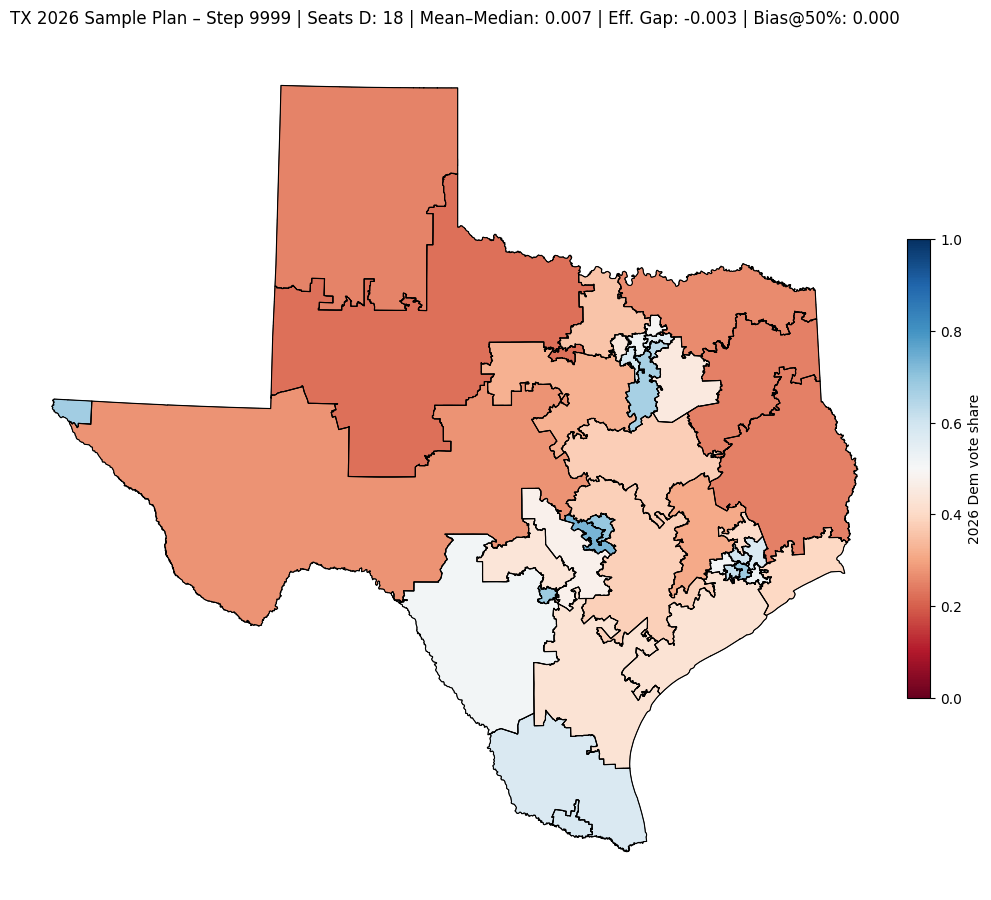

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path


# funcs
def _choose_metrics_df(globs):
    want_any = [
        {"dem20_seats", "dem_seats"},
        {"meanmedian", "mean_median"},
        {"effgap", "efficiency_gap"},
        {"bias50", "partisan_bias"},
        {"step"},
    ]
    def has_any(df):
        cols = set(df.columns)
        return all(len(cols & opt) > 0 for opt in want_any)
    candidates = []
    for name in ["df_extra", "df_out", "df"]:
        if name in globs and isinstance(globs[name], pd.DataFrame) and not globs[name].empty:
            candidates.append((name, globs[name]))
    if not candidates:
        raise ValueError("No metrics dataframe found (df_extra / df_out / df). Run the chain first.")
    best = next(((n, d) for n, d in candidates if has_any(d)), None)
    if best is None:
        # fallback to the one with the largest 'step'
        best = max(candidates, key=lambda nd: nd[1]["step"].max() if "step" in nd[1] else -1)
    print(f"Using metrics from: {best[0]} (rows={len(best[1])})")
    return best[1]

def _get(m, keys, default=np.nan):
    for k in keys:
        if k in m:
            return m[k]
    return default


# pick metrics for step 9999
metrics_df = _choose_metrics_df(globals())

TARGET_STEP = 9999
if TARGET_STEP not in metrics_df["step"].values:
    raise ValueError(
        f"Step {TARGET_STEP} not found in metrics_df['step']. "
        f"Available steps: {metrics_df['step'].min()}..{metrics_df['step'].max()}"
    )

metrics_row = metrics_df.loc[metrics_df["step"] == TARGET_STEP].iloc[0]
last_step = TARGET_STEP   # just for the title


# load plan for step 9999
plan_path = Path("./outputs/TX/tx_2020_sample_plan_step9999.gpkg")  # <- file you saved in the chain
if not plan_path.exists():
    raise FileNotFoundError(f"Plan file for step {TARGET_STEP} not found: {plan_path}")

plan = gpd.read_file(plan_path, engine="pyogrio")

if "district" not in plan.columns:
    # try common fallbacks
    for alt in ["DISTRICT", "district_id", "DistID"]:
        if alt in plan.columns:
            plan = plan.rename(columns={alt: "district"})
            break
if "district" not in plan.columns:
    raise KeyError("`plan` is missing a 'district' field.")


# ensure votes on plan
need_cols = {"PRES20D", "PRES20R"}
if not need_cols.issubset(plan.columns):
    if "gdf" not in globals() or not isinstance(gdf, gpd.GeoDataFrame):
        raise KeyError(
            "`plan` is missing PRES20D/PRES20R and `gdf` is not available "
            "to rebuild them. Please keep `gdf` from earlier cells in memory."
        )
    if not {"PRES20D","PRES20R"}.issubset(gdf.columns):
        raise KeyError("`gdf` lacks PRES20D/PRES20R; attach votes to VTDs before plotting.")

    gdf2 = gdf.copy()
    if plan.crs is None:
        raise ValueError("`plan` has no CRS; set a CRS before spatial join.")
    if gdf2.crs != plan.crs:
        gdf2 = gdf2.to_crs(plan.crs)

    pts = gdf2.geometry.representative_point()
    pts_gdf = gpd.GeoDataFrame(
        gdf2[["PRES20D","PRES20R"]].copy(), geometry=pts, crs=gdf2.crs
    )
    tag = gpd.sjoin(
        pts_gdf, plan[["district","geometry"]],
        predicate="within", how="left"
    )
    grp = tag.groupby("district")[["PRES20D","PRES20R"]].sum().reset_index()
    plan = plan.merge(grp, on="district", how="left")


# compute two-party shares
if "dist_dem20_share" not in plan.columns:
    two_party = (plan["PRES20D"] + plan["PRES20R"]).replace(0, np.nan)
    plan["dist_dem20_share"] = plan["PRES20D"] / two_party


# plot 
fig, ax = plt.subplots(figsize=(10, 10))
vmin, vmax = 0.0, 1.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdBu  # 0=red (R), 1=blue (D)

# crisp borders under fill
plan.boundary.plot(ax=ax, linewidth=0.8, edgecolor="black")
plan.plot(column="dist_dem20_share", cmap=cmap, norm=norm,
          linewidth=0.4, edgecolor="black", ax=ax)

# colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
cbar.set_label("2026 Dem vote share")

# title from metrics
seats_D     = _get(metrics_row, ["dem20_seats", "dem_seats"])
mean_median = _get(metrics_row, ["meanmedian", "mean_median"])
eff_gap     = _get(metrics_row, ["effgap", "efficiency_gap"])
bias50      = _get(metrics_row, ["bias50", "partisan_bias"])

title_lines = [
    f"TX 2026 Sample Plan – Step {last_step}",
    f"Seats D: {int(seats_D) if pd.notna(seats_D) else 'n/a'}",
    f"Mean–Median: {mean_median:.3f}" if pd.notna(mean_median) else "Mean–Median: n/a",
    f"Eff. Gap: {eff_gap:.3f}" if pd.notna(eff_gap) else "Eff. Gap: n/a",
    f"Bias@50%: {bias50:.3f}" if pd.notna(bias50) else "Bias@50%: n/a",
]
ax.set_title(" | ".join(title_lines), fontsize=12)
ax.set_axis_off()
plt.tight_layout()

# save 
out_dir = Path("./outputs/TX")
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "tx_2020_sample_plan_step9999_vote_shares.png"
plt.savefig(out_png.as_posix(), dpi=200)
print("Saved figure to:", out_png.as_posix())
plt.show()


Using metrics from: df_extra (rows=10000)


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Saved figure to: outputs/TX/tx_2020_tx_2020_sample_plan_14D_vote_shares.png


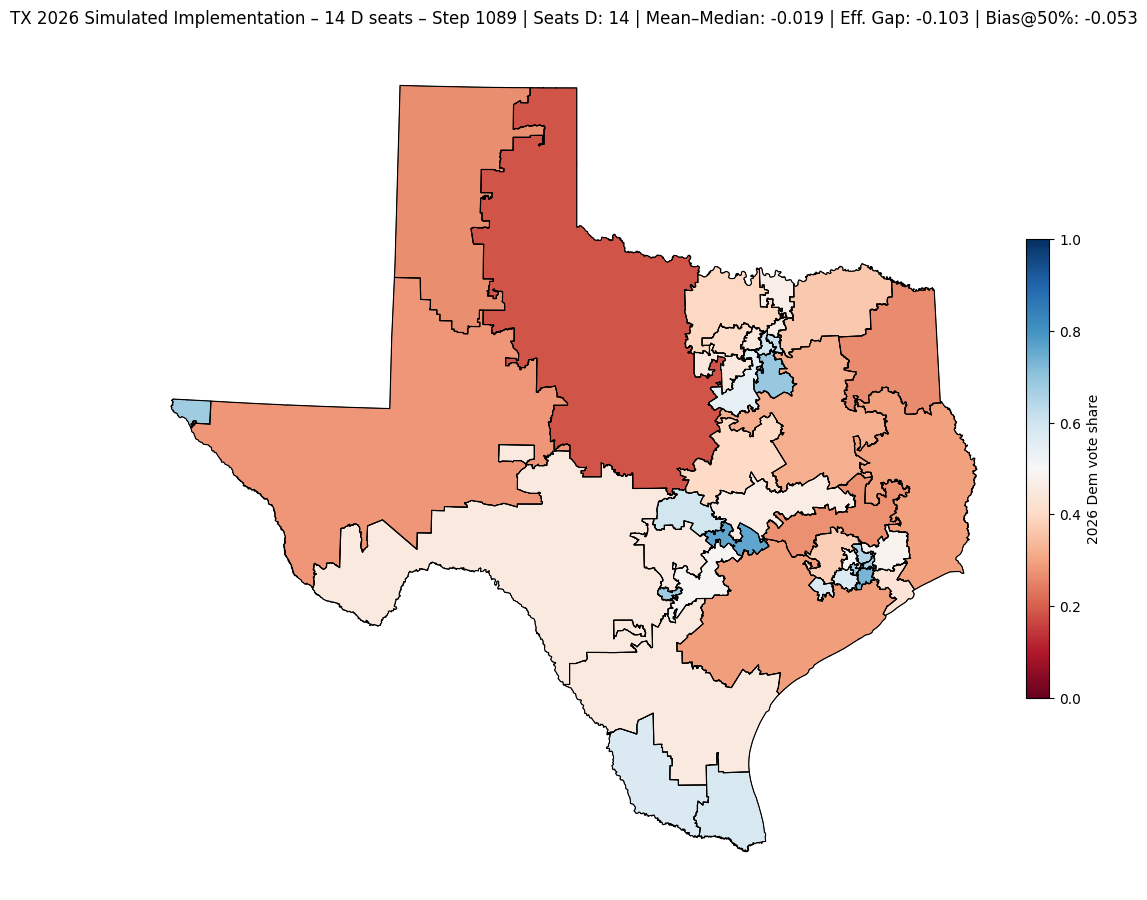

Using metrics from: df_extra (rows=10000)


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Saved figure to: outputs/TX/tx_2020_tx_2020_sample_plan_22D_vote_shares.png


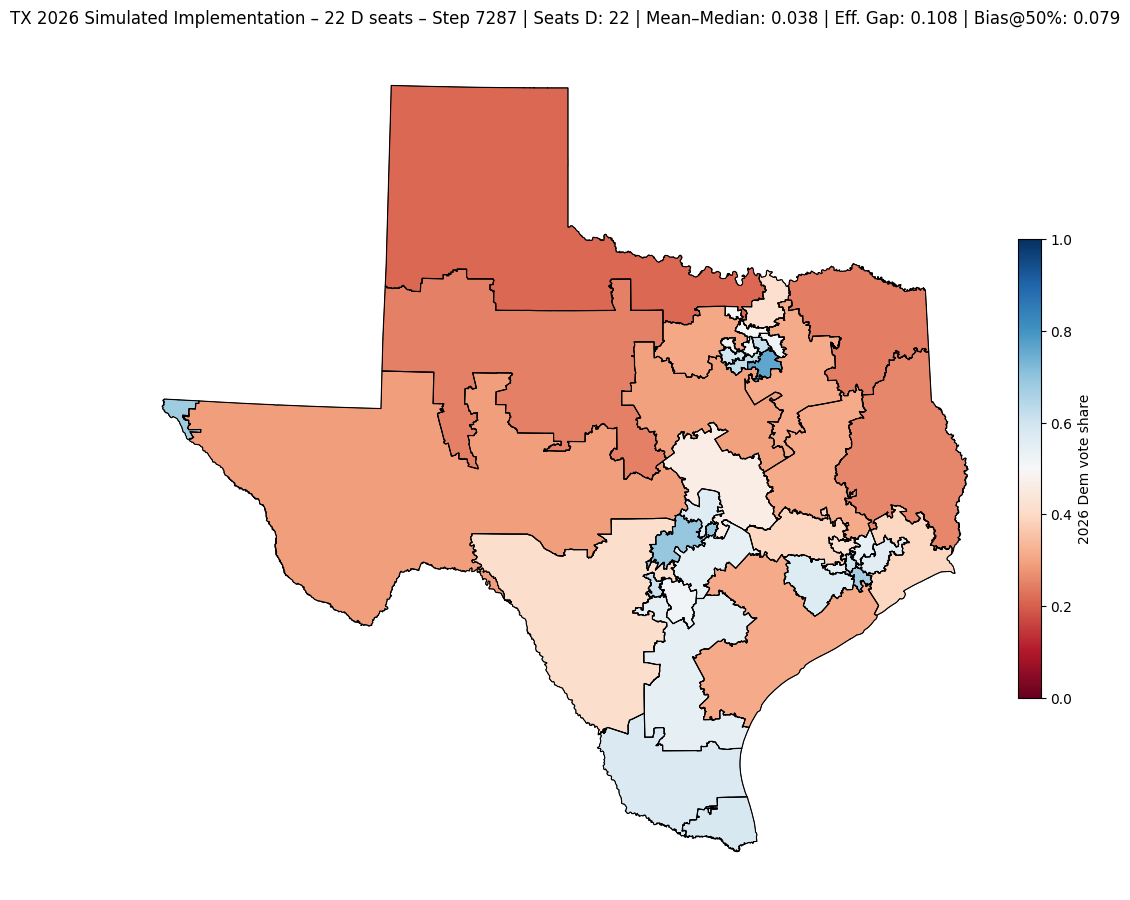

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path


# funcs
def _choose_metrics_df(globs):
    want_any = [
        {"dem20_seats", "dem_seats"},
        {"meanmedian", "mean_median"},
        {"effgap", "efficiency_gap"},
        {"bias50", "partisan_bias"},
        {"step"},
    ]
    def has_any(df):
        cols = set(df.columns)
        return all(len(cols & opt) > 0 for opt in want_any)
    candidates = []
    for name in ["df_extra", "df_out", "df"]:
        if name in globs and isinstance(globs[name], pd.DataFrame) and not globs[name].empty:
            candidates.append((name, globs[name]))
    if not candidates:
        raise ValueError("No metrics dataframe found (df_extra / df_out / df). Run the chain first.")
    best = next(((n, d) for n, d in candidates if has_any(d)), None)
    if best is None:
        best = max(candidates, key=lambda nd: nd[1]["step"].max() if "step" in nd[1] else -1)
    print(f"Using metrics from: {best[0]} (rows={len(best[1])})")
    return best[1]


def _get(m, keys, default=np.nan):
    for k in keys:
        if k in m:
            return m[k]
    return default


def _ensure_votes_on_plan(plan, gdf):
    """Ensure PRES20D/PRES20R are present on the district plan."""
    need_cols = {"PRES20D", "PRES20R"}
    if need_cols.issubset(plan.columns):
        return plan

    if gdf is None or not isinstance(gdf, gpd.GeoDataFrame):
        raise KeyError(
            "`plan` is missing PRES20D/PRES20R and `gdf` is not available "
            "to rebuild them. Please keep `gdf` from earlier cells in memory."
        )
    if not {"PRES20D","PRES20R"}.issubset(gdf.columns):
        raise KeyError("`gdf` lacks PRES20D/PRES20R; attach votes to VTDs before plotting.")

    gdf2 = gdf.copy()
    if plan.crs is None:
        raise ValueError("`plan` has no CRS; set a CRS before spatial join.")
    if gdf2.crs != plan.crs:
        gdf2 = gdf2.to_crs(plan.crs)

    pts = gdf2.geometry.representative_point()
    pts_gdf = gpd.GeoDataFrame(
        gdf2[["PRES20D","PRES20R"]].copy(), geometry=pts, crs=gdf2.crs
    )
    tag = gpd.sjoin(
        pts_gdf, plan[["district","geometry"]],
        predicate="within", how="left"
    )
    grp = tag.groupby("district")[["PRES20D","PRES20R"]].sum().reset_index()
    plan = plan.merge(grp, on="district", how="left")
    return plan


def _plot_plan(plan, metrics_row, title_prefix, out_name):
    """Generic plotting helper for one plan."""
    fig, ax = plt.subplots(figsize=(10, 10))
    vmin, vmax = 0.0, 1.0
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.RdBu  # 0=red (R), 1=blue (D)

    # borders
    plan.boundary.plot(ax=ax, linewidth=0.8, edgecolor="black")
    plan.plot(column="dist_dem20_share", cmap=cmap, norm=norm,
              linewidth=0.4, edgecolor="black", ax=ax)

    # colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
    cbar.set_label("2026 Dem vote share")

    # title
    seats_D     = _get(metrics_row, ["dem20_seats", "dem_seats"])
    mean_median = _get(metrics_row, ["meanmedian", "mean_median"])
    eff_gap     = _get(metrics_row, ["effgap", "efficiency_gap"])
    bias50      = _get(metrics_row, ["bias50", "partisan_bias"])
    step        = int(metrics_row["step"]) if "step" in metrics_row else None

    title_lines = [
        f"{title_prefix} – Step {step}" if step is not None else title_prefix,
        f"Seats D: {int(seats_D) if pd.notna(seats_D) else 'n/a'}",
        f"Mean–Median: {mean_median:.3f}" if pd.notna(mean_median) else "Mean–Median: n/a",
        f"Eff. Gap: {eff_gap:.3f}" if pd.notna(eff_gap) else "Eff. Gap: n/a",
        f"Bias@50%: {bias50:.3f}" if pd.notna(bias50) else "Bias@50%: n/a",
    ]
    ax.set_title(" | ".join(title_lines), fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()

    out_dir = Path("./outputs/TX")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_png = out_dir / out_name
    plt.savefig(out_png.as_posix(), dpi=200)
    print("Saved figure to:", out_png.as_posix())
    plt.show()


def plot_saved_plan(plan_path_str, label_prefix):
    """Load a saved GPKG, match its step to metrics_df, and plot."""
    metrics_df = _choose_metrics_df(globals())

    plan_path = Path(plan_path_str)
    if not plan_path.exists():
        raise FileNotFoundError(f"Plan file not found: {plan_path}")

    # read plan
    plan = gpd.read_file(plan_path, engine="pyogrio")

    # ensure district column
    if "district" not in plan.columns:
        for alt in ["DISTRICT", "district_id", "DistID"]:
            if alt in plan.columns:
                plan = plan.rename(columns={alt: "district"})
                break
    if "district" not in plan.columns:
        raise KeyError("`plan` is missing a 'district' field.")

    # find step for this plan
    if "step" in plan.columns and "step" in metrics_df.columns:
        step_for_plan = int(plan["step"].iloc[0])
        if step_for_plan not in metrics_df["step"].values:
            raise ValueError(f"Step {step_for_plan} from plan file not in metrics_df.")
        metrics_row = metrics_df.loc[metrics_df["step"] == step_for_plan].iloc[0]
    else:
        # fallback: pick the earliest row with the same seat count
        seat_col = "dem20_seats" if "dem20_seats" in metrics_df.columns else "dem_seats"
        if "14" in plan_path.name:
            target_seats = 14
        elif "22" in plan_path.name:
            target_seats = 22
        else:
            raise ValueError("Plan has no 'step' and filename doesn't encode seats.")
        subset = metrics_df.loc[metrics_df[seat_col] == target_seats]
        if subset.empty:
            raise ValueError(f"No metrics row with {target_seats} Dem seats.")
        metrics_row = subset.sort_values("step").iloc[0]

    # ensure votes on plan
    gdf = globals().get("gdf", None)
    plan = _ensure_votes_on_plan(plan, gdf)

    # compute two-party share
    if "dist_dem20_share" not in plan.columns:
        two_party = (plan["PRES20D"] + plan["PRES20R"]).replace(0, np.nan)
        plan["dist_dem20_share"] = plan["PRES20D"] / two_party

    # output name
    out_name = f"tx_2020_{plan_path.stem}_vote_shares.png"
    _plot_plan(plan, metrics_row, title_prefix=label_prefix, out_name=out_name)


# call for 14-seat and 22-seat plans
plot_saved_plan(
    "./outputs/TX/tx_2020_sample_plan_14D.gpkg",
    label_prefix="TX 2026 Simulated Implementation – 14 D seats"
)

plot_saved_plan(
    "./outputs/TX/tx_2020_sample_plan_22D.gpkg",
    label_prefix="TX 2026 Simulated Implementation – 22 D seats"
)


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


Saved figure to: outputs/TX/tx_2026_enacted_PLANC2333_vote_shares.png


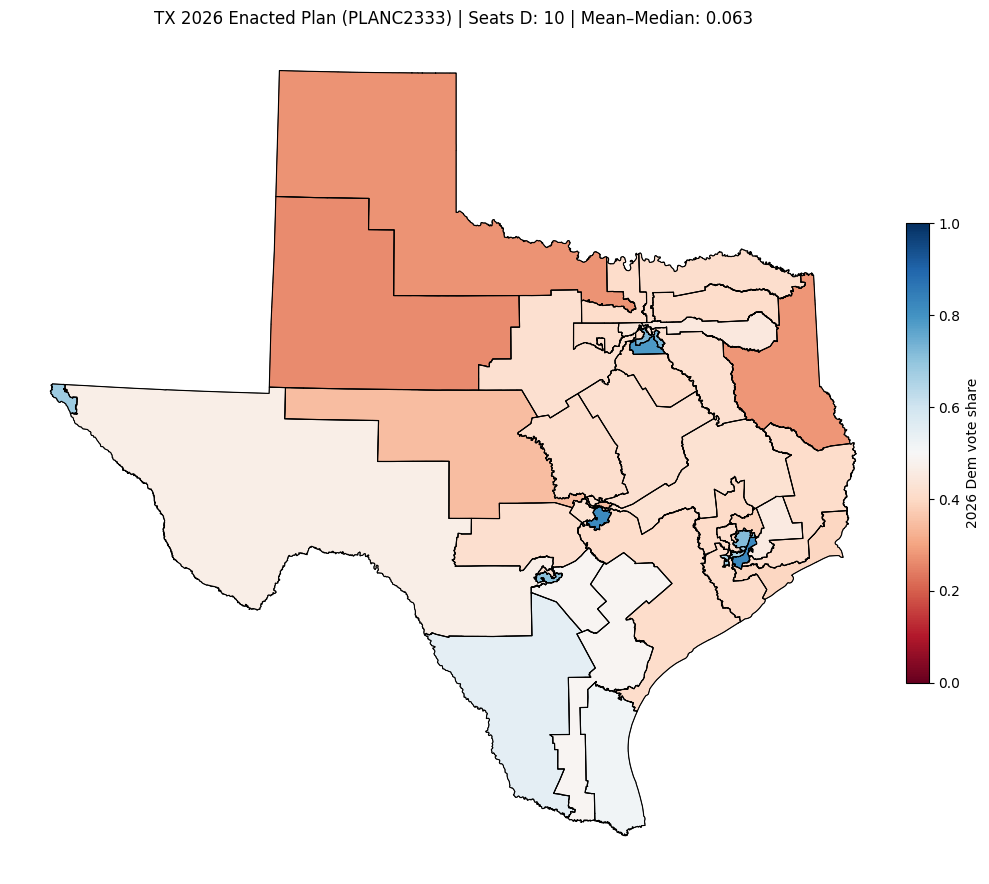

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path

# basic checks 
if "gdf" not in globals() or not isinstance(gdf, gpd.GeoDataFrame):
    raise KeyError("Need `gdf` (VTD GeoDataFrame) with PRES20D/PRES20R in memory.")
if not {"PRES20D", "PRES20R"}.issubset(gdf.columns):
    raise KeyError("`gdf` must contain PRES20D and PRES20R before plotting the enacted plan.")

# load enacted PLANC2333 
enacted_path = Path(r"./inputs/TX/tx_cong_adopted_2025/PLANC2333/PLANC2333.shp")

if not enacted_path.exists():
    raise FileNotFoundError(f"Cannot find PLANC2333 at: {enacted_path}")

plan = gpd.read_file(enacted_path, engine="pyogrio")

# Try to standardize district column name
if "district" not in plan.columns:
    for alt in ["DISTRICT", "DIST", "USCD", "CD", "CDIST", "District"]:
        if alt in plan.columns:
            plan = plan.rename(columns={alt: "district"})
            break
if "district" not in plan.columns:
    raise KeyError("PLANC2333 file has no recognizable district column. "
                   "Add/rename a column to 'district' or adjust the code.")

# attach 2020 votes to enacted districts
gdf2 = gdf.copy()

# CRS harmonization
if plan.crs is None:
    raise ValueError("PLANC2333 has no CRS; set the correct CRS before joining.")
if gdf2.crs != plan.crs:
    gdf2 = gdf2.to_crs(plan.crs)

# Represent each VTD by a point and join to enacted districts
pts = gdf2.geometry.representative_point()
pts_gdf = gpd.GeoDataFrame(
    gdf2[["PRES20D", "PRES20R"]].copy(),
    geometry=pts,
    crs=gdf2.crs,
)

tag = gpd.sjoin(
    pts_gdf,
    plan[["district", "geometry"]],
    predicate="within",
    how="left",
)

# Aggregate votes by enacted district and merge back to `plan`
grp = (
    tag.groupby("district")[["PRES20D", "PRES20R"]]
       .sum()
       .reset_index()
)
plan = plan.merge(grp, on="district", how="left")

# compute 2020 Dem two-party share
two_party = (plan["PRES20D"] + plan["PRES20R"]).replace(0, np.nan)
plan["dist_dem20_share"] = plan["PRES20D"] / two_party

# enacted metrics from PLANC2333
rep = plan["PRES20R"].astype(float)
two = dem + rep
share_D = dem / two.replace(0, np.nan)

enacted_seats_D = int((dem > rep).sum())
enacted_mean_dem_share = float(share_D.mean(skipna=True))
enacted_meanmedian = float(share_D.mean(skipna=True) - share_D.median(skipna=True))

# plot
fig, ax = plt.subplots(figsize=(10, 10))
vmin, vmax = 0.0, 1.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdBu  # 0=red (R), 1=blue (D)

# borders
plan.boundary.plot(ax=ax, linewidth=0.8, edgecolor="black")
plan.plot(
    column="dist_dem20_share",
    cmap=cmap,
    norm=norm,
    linewidth=0.4,
    edgecolor="black",
    ax=ax,
)

# colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
cbar.set_label("2026 Dem vote share")

# title 
title_lines = [
    "TX 2026 Enacted Plan (PLANC2333)",
    f"Seats D: {enacted_seats_D}",
    f"Mean–Median: {enacted_meanmedian:.3f}",
]
ax.set_title(" | ".join(title_lines), fontsize=12)
ax.set_axis_off()
plt.tight_layout()

# save 
out_dir = Path("./outputs/TX")
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "tx_2026_enacted_PLANC2333_vote_shares.png"
plt.savefig(out_png.as_posix(), dpi=200)
print("Saved figure to:", out_png.as_posix())
plt.show()


Using AUS column: aus_NONWHITE_S_pm
Saved S± choropleth to: outputs/TX/tx_2020_sample_plan_aus_Spm_choropleth.png


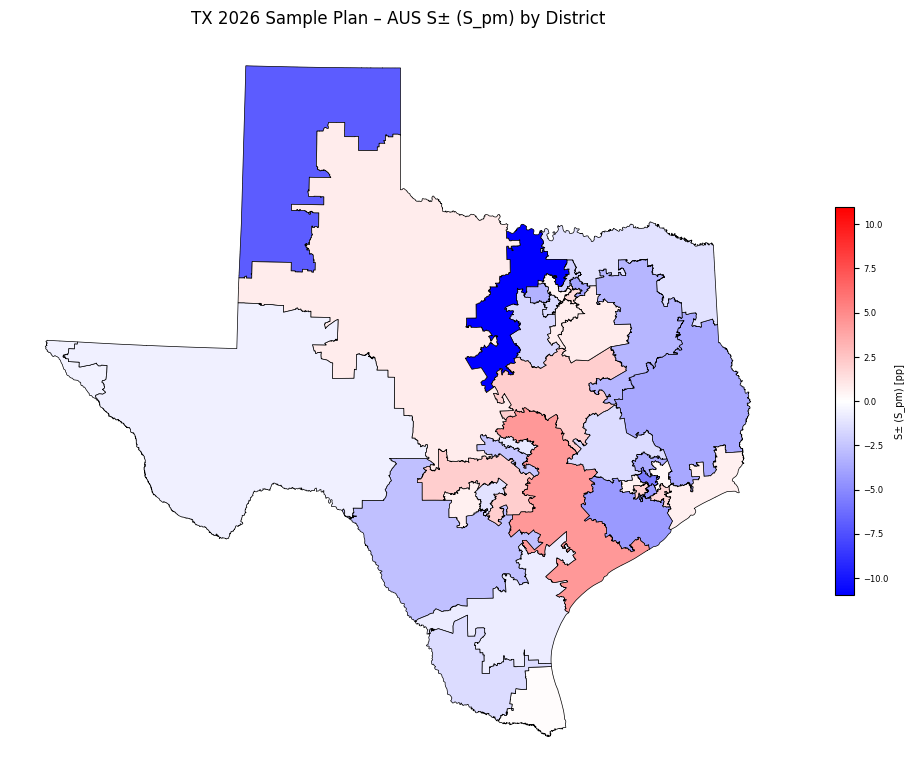

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import numpy as np
from pathlib import Path

# Load the sample AUS plan
plan_path = Path("./outputs/TX/tx_2020_sample_plan_with_aus.gpkg")
if not plan_path.exists():
    raise FileNotFoundError(f"Sample AUS plan not found at {plan_path}")

try:
    plan = gpd.read_file(plan_path, layer="districts", engine="pyogrio")
except Exception:
    plan = gpd.read_file(plan_path)

# Detect the S_pm column 
aus_cols = [c for c in plan.columns if c.startswith("aus_") and c.endswith("_S_pm")]
if not aus_cols:
    raise KeyError(
        f"No AUS S_pm column found. "
        f"Expected columns like 'aus_*_S_pm'. Found: {list(plan.columns)}"
    )

aus_col = aus_cols[0]
print(f"Using AUS column: {aus_col}")

# Symmetric color scale around 0
vmax = float(np.nanmax(np.abs(plan[aus_col])))
if vmax == 0:
    vmax = 1.0
vmin = -vmax

# Plot (Texas-style styling, see Saporito paper)
fig, ax = plt.subplots(figsize=(10, 10))

plan.plot(
    column=aus_col,
    ax=ax,
    cmap="bwr",
    linewidth=0.5,
    edgecolor="black",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    legend_kwds={
        "label": "",        # leave blank for custom label later
        "shrink": 0.40,     # shrink colorbar height per J request
    },
)

# shrink + restyle colorbar
cbar_ax = ax.get_figure().axes[-1]      # colorbar axis
box = cbar_ax.get_position()

# Make colorbar narrower & shift right 
cbar_ax.set_position([
    box.x0 + 0.01,
    box.y0,
    box.width * 0.50,      # half width
    box.height,
])

# Smaller ticks + label
cbar_ax.tick_params(labelsize=6)
cbar_ax.set_ylabel("S± (S_pm) [pp]", fontsize=7)

# title 
ax.set_title("TX 2026 Sample Plan – AUS S± (S_pm) by District", fontsize=12)
ax.set_axis_off()
plt.tight_layout()

out_dir = Path("./outputs/TX")
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "tx_2020_sample_plan_aus_Spm_choropleth.png"
plt.savefig(out_png.as_posix(), dpi=200)
print("Saved S± choropleth to:", out_png.as_posix())
plt.show()


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
from gerrychain import Partition
from gerrychain.metrics import mean_median, efficiency_gap, partisan_bias

# Preconditions
assert "gdf" in globals(), "`gdf` (VTD GeoDataFrame) must exist."
assert "graph" in globals(), "`graph` (GerryChain Graph) must exist."
assert "my_updaters" in globals(), "`my_updaters` (with PRES20 Election updater) must exist."
assert {"PRES20D", "PRES20R"}.issubset(gdf.columns), "gdf must have PRES20D/PRES20R."

# Election alias on this partition 
if "PRES20" in my_updaters:
    ELECTION_ALIAS = "PRES20"
elif "pres20" in my_updaters:
    ELECTION_ALIAS = "pres20"
else:
    raise KeyError("Neither 'PRES20' nor 'pres20' updater found in my_updaters.")

# Build a Partition that matches PLANC2333
planc_path = Path(r"./inputs/TX/tx_cong_adopted_2025/PLANC2333/PLANC2333.shp")
if not planc_path.exists():
    raise FileNotFoundError(f"Cannot find PLANC2333 at {planc_path}")

plan_planc = gpd.read_file(planc_path, engine="pyogrio")

# Standardize district column name
if "district" not in plan_planc.columns:
    for alt in ["DISTRICT", "DIST", "USCD", "CD", "CDIST", "District"]:
        if alt in plan_planc.columns:
            plan_planc = plan_planc.rename(columns={alt: "district"})
            break
if "district" not in plan_planc.columns:
    raise KeyError("PLANC2333 has no recognizable district column; add/rename one to 'district'.")

# Align CRS for spatial join
gdf2 = gdf.copy()
if plan_planc.crs is None:
    raise ValueError("PLANC2333 has no CRS; set it correctly before joining.")
if gdf2.crs != plan_planc.crs:
    gdf2 = gdf2.to_crs(plan_planc.crs)

# Represent each VTD by a point and tag with enacted district
pts = gdf2.geometry.representative_point()
pts_gdf = gpd.GeoDataFrame(
    gdf2[["TOTPOP"]].copy(),  # payload is irrelevant here, index + geometry lead
    geometry=pts,
    crs=gdf2.crs,
)

tag = gpd.sjoin(
    pts_gdf,
    plan_planc[["district", "geometry"]],
    predicate="within",
    how="left",
)

# Build node > district assignment (keys must match graph node ids = gdf index)
assign_series = tag["district"].reindex(gdf.index)
if assign_series.isna().any():
    n_na = int(assign_series.isna().sum())
    print(f"[warn] {n_na} VTDs did not match any PLANC2333 district (NaN); "
          "these nodes will be omitted from the Partition.")
    assignment_planc = {i: d for i, d in assign_series.items() if pd.notna(d)}
else:
    assignment_planc = assign_series.to_dict()

print("Number of nodes in PLANC2333 assignment:", len(assignment_planc))

# Build the Partition for PLANC2333
part_planc = Partition(graph, assignment=assignment_planc, updaters=my_updaters)

# Compute metrics from PLANC2333
enacted_true = {}

# Core fairness trio 
try:
    enacted_true["mean_median"]    = float(mean_median(part_planc[ELECTION_ALIAS]))
    enacted_true["efficiency_gap"] = float(efficiency_gap(part_planc[ELECTION_ALIAS]))
    enacted_true["partisan_bias"]  = float(partisan_bias(part_planc[ELECTION_ALIAS]))
except Exception as e:
    print("[warn] Could not compute fairness metrics for PLANC2333:", e)

# GEO counts 
if "geo_D" in part_planc.updaters and "geo_R" in part_planc.updaters:
    enacted_true["geo_D"] = int(part_planc["geo_D"])
    enacted_true["geo_R"] = int(part_planc["geo_R"])

# AUS counts & mean
aus_key = next((k for k in part_planc.updaters.keys() if k.startswith("aus_")), None)
if aus_key is None and "S_BVAP" in part_planc.updaters:
    aus_key = "S_BVAP"

if aus_key is not None:
    try:
        seg = part_planc[aus_key]   # {dist: {"S_pm": ..., ...}}
        svals = np.array([v["S_pm"] for v in seg.values()], dtype=float)
        enacted_true[f"{aus_key}_n_packed"]  = int((svals > 0).sum())
        enacted_true[f"{aus_key}_n_cracked"] = int((svals < 0).sum())
        enacted_true[f"{aus_key}_mean_pp"]   = float(np.nanmean(svals))
    except Exception as e:
        print(f"[warn] Could not compute AUS metrics for PLANC2333 from '{aus_key}':", e)

print("PLANC2333 ‘true enacted’ metrics:")
for k, v in enacted_true.items():
    print(f"  {k}: {v}")


Number of nodes in PLANC2333 assignment: 9007
PLANC2333 ‘true enacted’ metrics:
  mean_median: -0.06262276935904276
  efficiency_gap: -0.21959630986599896
  partisan_bias: -0.1842105263157895
  geo_D: 16
  geo_R: 1
  aus_NONWHITE_n_packed: 16
  aus_NONWHITE_n_cracked: 22
  aus_NONWHITE_mean_pp: -1.3260871194044184


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


Using metrics_df from: df_extra (cols=['step', 'cut_edges', 'max_abs_pop_dev_pct', 'dem20_seats', 'geo_D', 'geo_R', 'effgap', 'meanmedian', 'bias50', 'aus_NONWHITE_mean_pp', 'aus_NONWHITE_min_pp', 'aus_NONWHITE_max_pp'] …)
Enacted/seed plan metrics: {'mean_median': -0.06262276935904276, 'efficiency_gap': -0.21959630986599896, 'partisan_bias': -0.1842105263157895, 'geo_D': 16, 'geo_R': 1}
Saved: ./outputs/ensemble_histograms_with_geo_aus.png


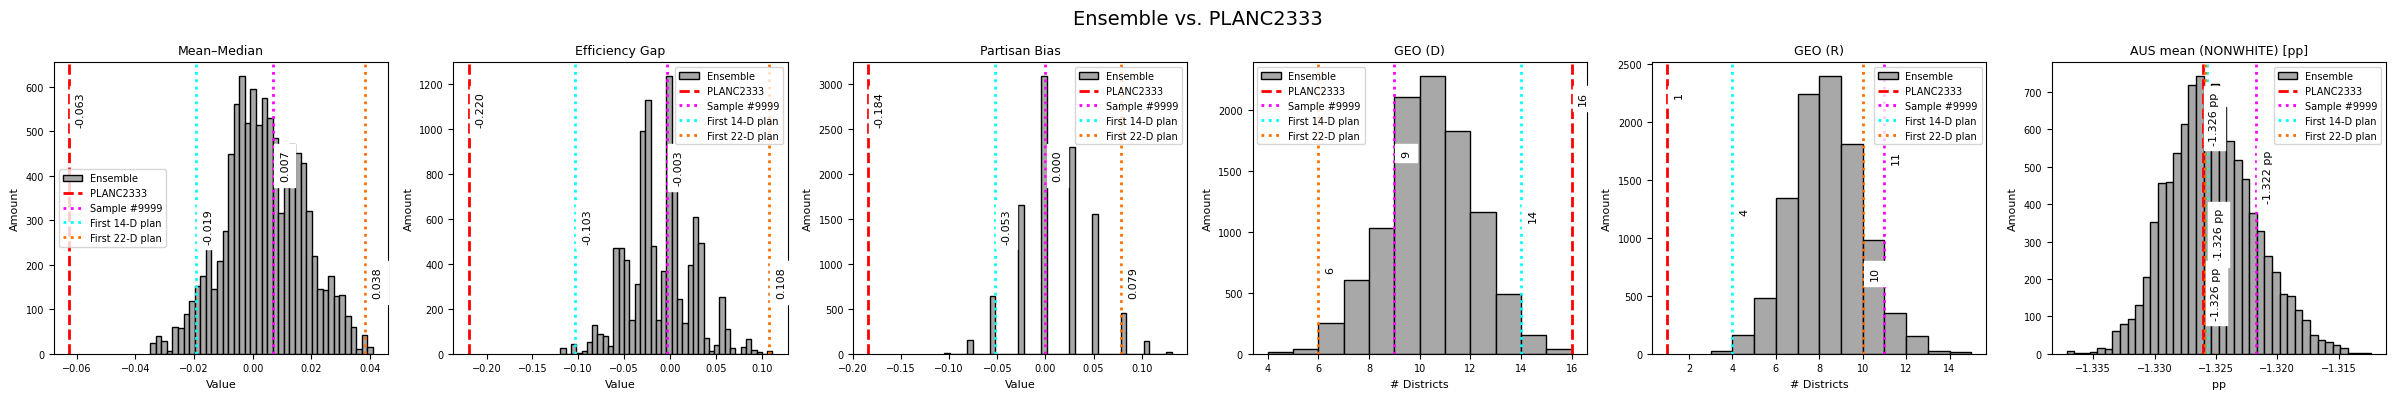

Saved: outputs\TX\single_hists\hist_mean_median.png
Saved: outputs\TX\single_hists\hist_efficiency_gap.png
Saved: outputs\TX\single_hists\hist_partisan_bias.png
Saved: outputs\TX\single_hists\hist_geo_D.png
Saved: outputs\TX\single_hists\hist_geo_R.png
Saved: outputs\TX\single_hists\hist_aus_NONWHITE_mean_pp.png


In [ ]:
# DeFord-style histograms + partisan 3 + GEO + AUS mean 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gerrychain.metrics import mean_median, efficiency_gap, partisan_bias

# Inputs & checks
# metrics_df: prefer df_extra (often includes GEO/AUS), then df_out, then df
metrics_df = None
for cand in ["df_extra", "df_out", "df"]:
    if cand in globals() and isinstance(globals()[cand], pd.DataFrame) and not globals()[cand].empty:
        metrics_df = globals()[cand].copy()
        print(f"Using metrics_df from: {cand} (cols={list(metrics_df.columns)[:12]} …)")
        break
if metrics_df is None:
    raise ValueError("No metrics dataframe found (df_extra / df_out / df). Run the chain first.")

if "part_planc" not in globals():
    raise KeyError("`initial` Partition not found. Run the chain setup cell first.")

# Determine election alias on the partition 
if "PRES20" in part_planc.updaters:
    ELECTION_ALIAS = "PRES20"
elif "pres20" in part_planc.updaters:
    ELECTION_ALIAS = "pres20"
else:
    raise KeyError("Neither 'PRES20' nor 'pres20' is present in initial.updaters.")

# Enacted/seed metrics 
enacted_metrics = {}
try:
    enacted_metrics.update({
        "mean_median":    mean_median(part_planc[ELECTION_ALIAS]),
        "efficiency_gap": efficiency_gap(part_planc[ELECTION_ALIAS]),
        "partisan_bias":  partisan_bias(part_planc[ELECTION_ALIAS]),
    })
except Exception as e:
    print("[warn] Could not compute enacted mean_median/eff_gap/partisan_bias:", e)

if "geo_D" in part_planc.updaters and "geo_R" in part_planc.updaters:
    enacted_metrics["geo_D"] = int(part_planc["geo_D"])
    enacted_metrics["geo_R"] = int(part_planc["geo_R"])

# S± (AUS) counts for enacted/seed plan
aus_key = next((k for k in part_planc.updaters.keys() if k.startswith("aus_")), None)
if aus_key is None and "S_BVAP" in part_planc.updaters:
    aus_key = "S_BVAP"
if aus_key is not None:
    try:
        seg0 = part_planc[aus_key]  # {dist: {"S_pm", ...}}
        svals0 = np.array([v["S_pm"] for v in seg0.values()], dtype=float)
        enacted_metrics[f"{aus_key}_n_packed"]  = int((svals0 > 0).sum())
        enacted_metrics[f"{aus_key}_n_cracked"] = int((svals0 < 0).sum())
        # also the enacted AUS mean (pp)
        enacted_metrics[f"{aus_key}_mean_pp"] = float(np.nanmean(svals0))
    except Exception as e:
        print(f"[warn] Could not compute enacted S± from '{aus_key}':", e)

print("Enacted/seed plan metrics:", {k: enacted_metrics[k] for k in enacted_metrics.keys() if k in ["mean_median","efficiency_gap","partisan_bias","geo_D","geo_R"]})

# Normalize column names in metrics_df 
col_aliases = {
    # fairness trio
    "mean_median":    ["mean_median", "meanmedian"],
    "efficiency_gap": ["efficiency_gap", "effgap"],
    "partisan_bias":  ["partisan_bias", "bias50"],
    # GEO integers
    "geo_D": ["geo_D"],
    "geo_R": ["geo_R"],
}
for canon, options in col_aliases.items():
    if canon not in metrics_df.columns:
        for opt in options:
            if opt in metrics_df.columns:
                metrics_df[canon] = metrics_df[opt]
                break

# Try to detect AUS mean column(s), e.g., "aus_BLACK_mean_pp"
# Allows for personal choice of nonwhite/black/asian/etc. 
aus_mean_cols = [c for c in metrics_df.columns if c.endswith("_mean_pp") and c.startswith("aus_")]

# Pull AUS counts
int_metric_candidates = []
if aus_key is not None:
    int_metric_candidates.extend([f"{aus_key}_n_packed", f"{aus_key}_n_cracked"])
int_metric_candidates.extend(["geo_D", "geo_R"])

# Attempt merging counts from other frames if missing
missing_ints = [c for c in int_metric_candidates if c not in metrics_df.columns]
if missing_ints:
    merged = False
    if "df" in globals() and isinstance(df, pd.DataFrame) and "step" in df.columns and "step" in metrics_df.columns:
        avail = [c for c in missing_ints if c in df.columns]
        if avail:
            metrics_df = metrics_df.merge(df[["step"] + avail], on="step", how="left")
            merged = True
    if (not merged) and "records" in globals() and isinstance(records, list) and len(records) > 0 and "step" in metrics_df.columns:
        rec_df = pd.DataFrame(records)
        avail = [c for c in missing_ints if c in rec_df.columns]
        if avail:
            metrics_df = metrics_df.merge(rec_df[["step"] + avail], on="step", how="left")
            merged = True

# Choose a sampled plan from the chain 
SAMPLED_STEP = int(metrics_df["step"].max())
sample_row = metrics_df.loc[metrics_df["step"] == SAMPLED_STEP].iloc[0]

# Build a dict of sampled metrics 
sample_metrics = {}
for m in metrics_df.columns:
    if m in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"] or \
       (m.startswith("aus_") and (m.endswith("_n_packed") or m.endswith("_n_cracked") or m.endswith("_mean_pp"))):
        val = sample_row.get(m, np.nan)
        if pd.notna(val):
            sample_metrics[m] = float(val)

# first 14-seat and 22-seat plans metrics 
metrics_14 = {}
metrics_22 = {}
seat_col = "dem20_seats" if "dem20_seats" in metrics_df.columns else None

row14 = None
row22 = None
if seat_col is not None:
    df_seats = metrics_df.dropna(subset=[seat_col])

    if (df_seats[seat_col] == 14).any():
        row14 = df_seats.loc[df_seats[seat_col] == 14].sort_values("step").iloc[0]
    if (df_seats[seat_col] == 22).any():
        row22 = df_seats.loc[df_seats[seat_col] == 22].sort_values("step").iloc[0]

    if row14 is not None:
        for m in metrics_df.columns:
            if m in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"] or \
               (m.startswith("aus_") and (m.endswith("_n_packed") or m.endswith("_n_cracked") or m.endswith("_mean_pp"))):
                val = row14.get(m, np.nan)
                if pd.notna(val):
                    metrics_14[m] = float(val)

    if row22 is not None:
        for m in metrics_df.columns:
            if m in ["mean_median", "efficiency_gap", "partisan_bias", "geo_D", "geo_R"] or \
               (m.startswith("aus_") and (m.endswith("_n_packed") or m.endswith("_n_cracked") or m.endswith("_mean_pp"))):
                val = row22.get(m, np.nan)
                if pd.notna(val):
                    metrics_22[m] = float(val)

# metrics to plot
metrics_to_plot = []
for canon in ["mean_median", "efficiency_gap", "partisan_bias"]:
    if canon in metrics_df.columns:
        metrics_to_plot.append(canon)
for m in ["geo_D", "geo_R"]:
    if m in metrics_df.columns:
        metrics_to_plot.append(m)
for m in int_metric_candidates:
    if m in metrics_df.columns and m not in metrics_to_plot:
        metrics_to_plot.append(m)
# add AUS mean pp column(s) if present
metrics_to_plot.extend([m for m in aus_mean_cols if m not in metrics_to_plot])

if not metrics_to_plot:
    raise RuntimeError("No metrics available to plot after normalization. "
                       f"Columns are: {list(metrics_df.columns)}")

# titles
pretty_map = {
    "geo_D": "GEO (D)",
    "geo_R": "GEO (R)",
    "mean_median": "Mean–Median",
    "efficiency_gap": "Efficiency Gap",
    "partisan_bias": "Partisan Bias",
}
# AUS
for c in aus_mean_cols:
    # e.g., aus_BLACK_mean_pp -> "AUS mean (BLACK) [pp]"
    group = c.replace("aus_", "").replace("_mean_pp", "")
    pretty_map[c] = f"AUS mean ({group}) [pp]"
if aus_key is not None:
    pretty_map.setdefault(f"{aus_key}_n_packed",  "S± packed (count)")
    pretty_map.setdefault(f"{aus_key}_n_cracked", "S± cracked (count)")

# Plot 
plt.rcParams.update({
    "font.size": 8,       
    "axes.titlesize": 9,   # subplot titles
    "axes.labelsize": 8,  
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4 * len(metrics_to_plot), 4))
if len(metrics_to_plot) == 1:  # make axes iterable
    axes = [axes]

for ax, metric in zip(axes, metrics_to_plot):
    if metric not in metrics_df.columns:
        ax.set_visible(False)
        continue

    series = metrics_df[metric].dropna()
    is_int_metric = metric in (["geo_D", "geo_R"] + int_metric_candidates)
    is_aus_mean   = metric in aus_mean_cols

    # Binning
    if is_int_metric and len(series) > 0:
        lo, hi = int(series.min()), int(series.max())
        bins = np.arange(lo, hi + 2)  # integer bins
    else:
        bins = 40

    ax.hist(series, bins=bins, edgecolor="black", color="#A8A8A8", label="Ensemble")

    # Enacted overlay
    if metric in enacted_metrics:
        val = enacted_metrics[metric]
        ax.axvline(val, color="red", linestyle="--", linewidth=2, label="PLANC2333")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        offset = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(val):
            label_txt = f"{int(val)}"
        elif is_aus_mean and pd.notna(val):
            label_txt = f"{val:.3f} pp"
        else:
            label_txt = f"{val:.3f}" if pd.notna(val) else "n/a"
        ax.text(val + offset, ylim[1] * 0.9, label_txt,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    # Sampled plan overlay (last step)
    if metric in sample_metrics:
        sval = sample_metrics[metric]
        ax.axvline(sval, color="magenta", linestyle=":", linewidth=2,
                   label=f"Sample #{SAMPLED_STEP}")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        soffset = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(sval):
            slabel_txt = f"{int(sval)}"
        elif is_aus_mean and pd.notna(sval):
            slabel_txt = f"{sval:.3f} pp"
        else:
            slabel_txt = f"{sval:.3f}" if pd.notna(sval) else "n/a"
        ax.text(sval + soffset, ylim[1] * 0.7, slabel_txt,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    # first 14-D plan overlay
    if metric in metrics_14:
        v14 = metrics_14[metric]
        ax.axvline(v14, color="cyan", linestyle=":", linewidth=2,
                   label="First 14-D plan")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        off14 = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(v14):
            txt14 = f"{int(v14)}"
        elif is_aus_mean and pd.notna(v14):
            txt14 = f"{v14:.3f} pp"
        else:
            txt14 = f"{v14:.3f}" if pd.notna(v14) else "n/a"
        ax.text(v14 + off14, ylim[1] * 0.5, txt14,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    # first 22-D plan overlay
    if metric in metrics_22:
        v22 = metrics_22[metric]
        ax.axvline(v22, color="#FF6F00", linestyle=":", linewidth=2,
                   label="First 22-D plan")
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        off22 = (xlim[1] - xlim[0]) * 0.02
        if is_int_metric and pd.notna(v22):
            txt22 = f"{int(v22)}"
        elif is_aus_mean and pd.notna(v22):
            txt22 = f"{v22:.3f} pp"
        else:
            txt22 = f"{v22:.3f}" if pd.notna(v22) else "n/a"
        ax.text(v22 + off22, ylim[1] * 0.3, txt22,
                rotation=90, va="top", ha="left", fontsize=8, backgroundcolor="white")

    pretty_name = pretty_map.get(metric, metric.replace("_", " ").title())
    ax.set_title(pretty_name)
    ax.set_xlabel("# Districts" if is_int_metric else ("pp" if is_aus_mean else "Value"))
    ax.set_ylabel("Amount")
    ax.legend(loc="best")

plt.suptitle("Ensemble vs. PLANC2333", fontsize=14)
plt.tight_layout()
plt.savefig("./outputs/ensemble_histograms_with_geo_aus.png", dpi=200)
print("Saved: ./outputs/ensemble_histograms_with_geo_aus.png")
plt.show()

# Save each metric's histogram separately (legend beside)
out_dir = Path("./outputs/TX/single_hists")
out_dir.mkdir(parents=True, exist_ok=True)

for metric in metrics_to_plot:
    if metric not in metrics_df.columns:
        continue

    series = metrics_df[metric].dropna()
    is_int_metric = metric in (["geo_D", "geo_R"] + int_metric_candidates)
    is_aus_mean   = metric in aus_mean_cols

    # Binning
    if is_int_metric and len(series) > 0:
        lo, hi = int(series.min()), int(series.max())
        bins = np.arange(lo, hi + 2)
    else:
        bins = 40

    # width
    fig_m, ax_m = plt.subplots(figsize=(7, 4.5))

    # Ensemble histogram 
    ax_m.hist(
        series,
        bins=bins,
        edgecolor="black",
        color="#A8A8A8",
        label="Runs"
    )

    # Enacted (PLANC2333)
    if metric in enacted_metrics:
        val = enacted_metrics[metric]
        ax_m.axvline(
            val,
            color="red",
            linestyle="--",
            linewidth=2,
            label="PLANC2333"
        )

    # First 14-D plan 
    if metric in metrics_14:
        v14 = metrics_14[metric]
        ax_m.axvline(
            v14,
            color="cyan",
            linestyle=":",
            linewidth=2,
            label="Run #1089"
        )

    # First 22-D plan
    if metric in metrics_22:
        v22 = metrics_22[metric]
        ax_m.axvline(
            v22,
            color="#FF6F00",
            linestyle=":",
            linewidth=2,
            label="Run #7287"
        )

    # Sample
    if metric in sample_metrics:
        sval = sample_metrics[metric]
        ax_m.axvline(
            sval,
            color="magenta",
            linestyle=":",
            linewidth=2,
            label=f"Run #{SAMPLED_STEP}"
        )

    # Titles & other shenanigangs to ensure good aesthetics
    pretty_name = pretty_map.get(metric, metric.replace("_", " ").title())
    ax_m.set_title(pretty_name)
    ax_m.set_xlabel("# Districts" if is_int_metric else ("pp" if is_aus_mean else "Value"))
    ax_m.set_ylabel("Amount")
    fig_m.tight_layout()
    box = ax_m.get_position()
    ax_m.set_position([box.x0, box.y0, box.width * 0.78, box.height])
    ax_m.legend(
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),  # right of axes
        frameon=False
    )

    out_path = out_dir / f"hist_{metric}.png"
    fig_m.savefig(out_path, dpi=200)
    plt.close(fig_m)
    print("Saved:", out_path)



c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
C:\Users\kubak\AppData\Local\Temp\ipykernel_21276\479491612.py:152: UserWa

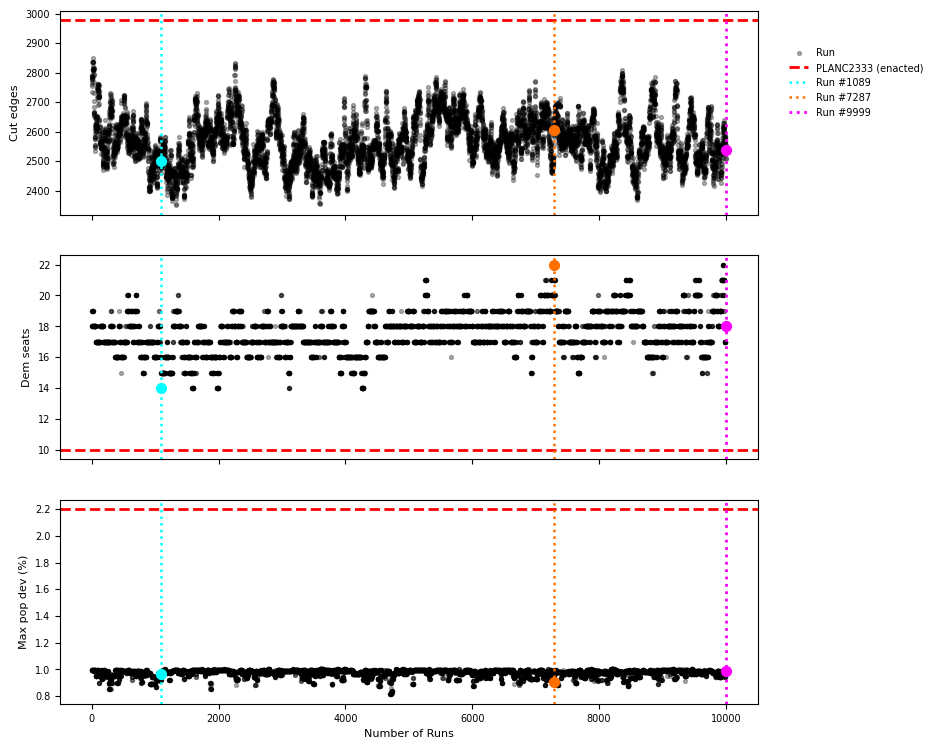

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

#  Basic setup & column names
seat_col = "dem20_seats"           # adjust if you renamed
col_dev  = "max_abs_pop_dev_pct"   # population deviation column

# Enacted (PLANC2333) metrics from part_planc
enacted_cut_edges = len(part_planc["cut_edges"])
enacted_seats     = int(part_planc["PRES20"].seats("D"))
pop_by_dist       = pd.Series(part_planc["population"], dtype=float)
ideal_pop         = pop_by_dist.mean()
enacted_pop_dev   = float(((pop_by_dist - ideal_pop) / ideal_pop).abs().max() * 100)

# Sample step 
TARGET_SAMPLE_STEP = 9999
if TARGET_SAMPLE_STEP not in metrics_df["step"].values:
    raise ValueError(f"Step {TARGET_SAMPLE_STEP} not found in metrics_df['step'].")

row_sample = metrics_df.loc[metrics_df["step"] == TARGET_SAMPLE_STEP].iloc[0]
sample_step      = int(row_sample["step"])
sample_cut_edges = row_sample["cut_edges"]
sample_seats     = row_sample[seat_col]
sample_pop_dev   = row_sample[col_dev]

# First 14-seat and 22-seat plans
row14 = None
row22 = None

if seat_col in metrics_df.columns:
    df_seats = metrics_df.dropna(subset=[seat_col])

    if (df_seats[seat_col] == 14).any():
        row14 = df_seats.loc[df_seats[seat_col] == 14].sort_values("step").iloc[0]

    if (df_seats[seat_col] == 22).any():
        row22 = df_seats.loc[df_seats[seat_col] == 22].sort_values("step").iloc[0]

# Plot diagnostics with vertical markers
fig, axs = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

# Cut edges
axs[0].scatter(
    metrics_df["step"], metrics_df["cut_edges"],
    s=8, alpha=0.3, color="black", label="Run"
)

# Enacted: horizontal line 
axs[0].axhline(
    enacted_cut_edges, color="red", linestyle="--", lw=2,
    label="PLANC2333 (enacted)"
)

# First 14-seat plan
if row14 is not None:
    axs[0].axvline(
        row14["step"], color="cyan", linestyle=":", lw=1.8,
        label="Run #1089"
    )
    axs[0].scatter(row14["step"], row14["cut_edges"], color="cyan", s=50, zorder=6)

# First 22-seat plan
if row22 is not None:
    axs[0].axvline(
        row22["step"], color="#FF6F00", linestyle=":", lw=1.8,
        label="Run #7287"
    )
    axs[0].scatter(row22["step"], row22["cut_edges"], color="#FF6F00", s=50, zorder=6)

# Sample step 9999: vertical line + point
axs[0].axvline(
    sample_step, color="magenta", linestyle=":", lw=2,
    label=f"Run #{sample_step}"
)
axs[0].scatter(sample_step, sample_cut_edges, color="magenta", s=50, zorder=5)

axs[0].set_ylabel("Cut edges")

# Democratic seats
axs[1].scatter(
    metrics_df["step"], metrics_df[seat_col],
    s=8, alpha=0.3, color="black"
)

axs[1].axhline(enacted_seats, color="red", linestyle="--", lw=2)
axs[1].axvline(sample_step, color="magenta", linestyle=":", lw=2)
axs[1].scatter(sample_step, sample_seats, color="magenta", s=50, zorder=5)

if row14 is not None:
    axs[1].axvline(row14["step"], color="cyan", linestyle=":", lw=1.8)
    axs[1].scatter(row14["step"], row14[seat_col], color="cyan", s=50, zorder=6)

if row22 is not None:
    axs[1].axvline(row22["step"], color="#FF6F00", linestyle=":", lw=1.8)
    axs[1].scatter(row22["step"], row22[seat_col], color="#FF6F00", s=50, zorder=6)

axs[1].set_ylabel("Dem seats")


# Population deviation
axs[2].scatter(
    metrics_df["step"], metrics_df[col_dev],
    s=8, alpha=0.3, color="black"
)

axs[2].axhline(enacted_pop_dev, color="red", linestyle="--", lw=2)
axs[2].axvline(sample_step, color="magenta", linestyle=":", lw=2)
axs[2].scatter(sample_step, sample_pop_dev, color="magenta", s=50, zorder=5)

if row14 is not None:
    axs[2].axvline(row14["step"], color="cyan", linestyle=":", lw=1.8)
    axs[2].scatter(row14["step"], row14[col_dev], color="cyan", s=50, zorder=6)

if row22 is not None:
    axs[2].axvline(row22["step"], color="#FF6F00", linestyle=":", lw=1.8)
    axs[2].scatter(row22["step"], row22[col_dev], color="#FF6F00", s=50, zorder=6)

axs[2].set_ylabel("Max pop dev (%)")
axs[2].set_xlabel("Number of Runs")

# Single legend just to the right of plots
handles, labels = axs[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles)) 

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="center left",
    bbox_to_anchor=(0.925, 0.8),
    frameon=False
)

plt.tight_layout(rect=[0.0, 0.0, 0.0, 0.0])



c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


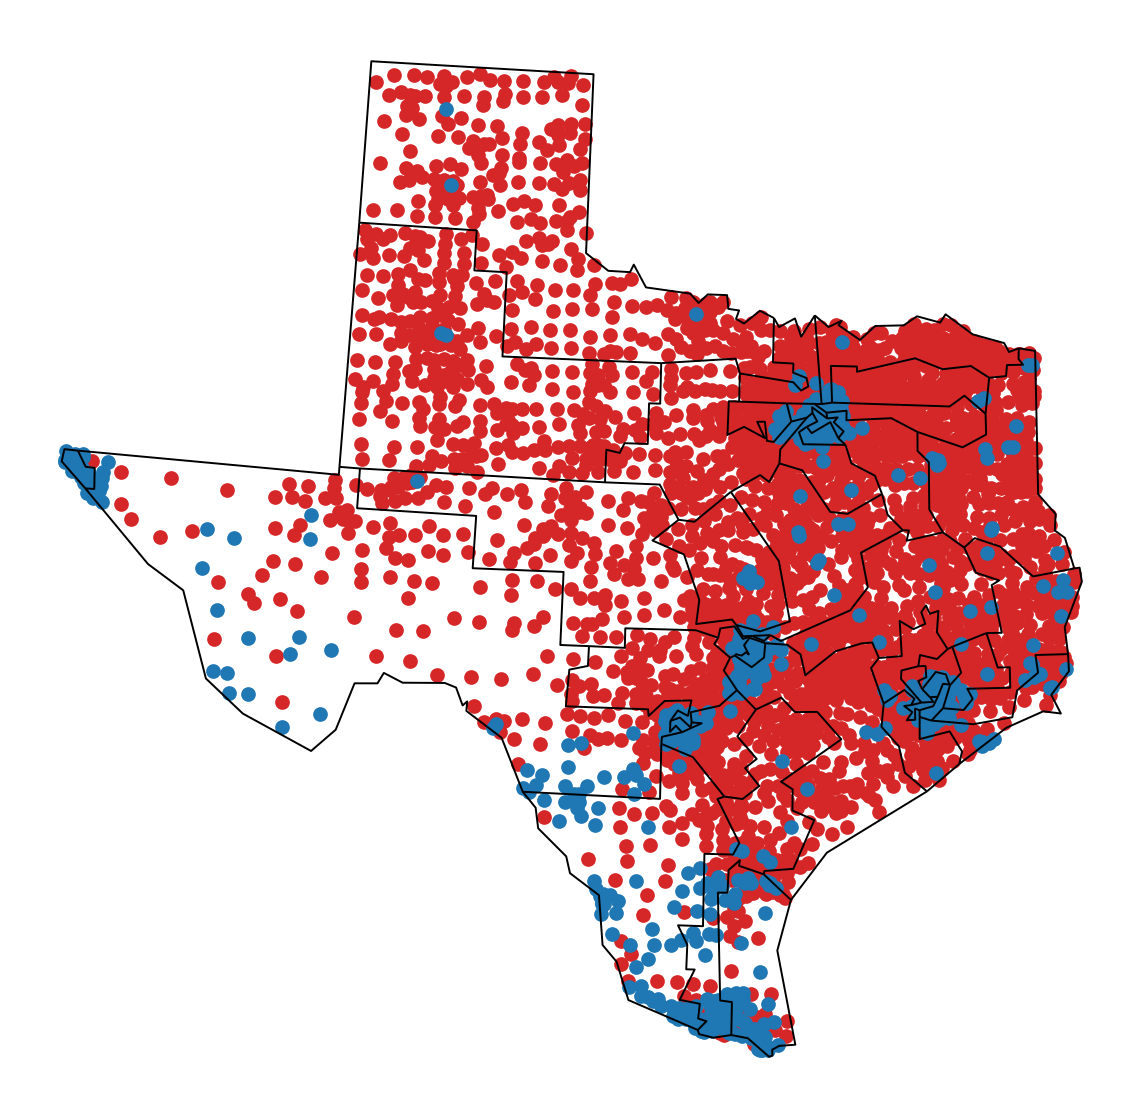

Saved: E:\wur_mgi-thesis_method_outlier-analysis\outputs\frontpage_planc2333_vtdwinner_dots_dropOverlaps.png
Dots plotted (after removing NA/TIE and overlaps): 3,201
Overlap control cell size (m): 8,000


In [ ]:
# Front page pic
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.ops import unary_union, linemerge

# Preconditions
assert "gdf" in globals(), "Expected a VTD GeoDataFrame named `gdf`."
required = {"geometry", "PRES20D", "PRES20R"}
missing = required - set(gdf.columns)
assert not missing, f"`gdf` is missing columns: {missing}"

CD116_FP = globals().get("CD116_FP", "./inputs/TX/tx_cong_adopted_2025/PLANC2333/PLANC2333.shp")
CD116_FP = Path(CD116_FP)
assert CD116_FP.exists(), f"Cannot find PLANC2333 shapefile at: {CD116_FP}"


# Load districts
districts = gpd.read_file(CD116_FP, engine="pyogrio")

cand = [c for c in districts.columns if c.lower() in {"district", "dist", "cd", "cd116fp", "cong_dist", "congress"}]
if cand:
    dist_col = cand[0]
else:
    num_cols = [c for c in districts.columns if pd.api.types.is_numeric_dtype(districts[c])]
    if not num_cols:
        raise ValueError(f"Could not infer district id column. Columns are: {list(districts.columns)}")
    dist_col = num_cols[0]

districts = districts.rename(columns={dist_col: "district"}).copy()


# Reproject for plotting + make points
TARGET_CRS = "EPSG:5070"  
gdf_plot = gdf.to_crs(TARGET_CRS) if gdf.crs != TARGET_CRS else gdf.copy()
dist_plot = districts.to_crs(TARGET_CRS) if districts.crs != TARGET_CRS else districts.copy()

vtd_pts = gdf_plot.copy()
vtd_pts["geometry"] = vtd_pts.geometry.representative_point()

# Assign district -> irrelevant now, was useful for a different idea
tagged = gpd.sjoin(
    vtd_pts[["PRES20D", "PRES20R", "geometry"]],
    dist_plot[["district", "geometry"]],
    how="left",
    predicate="within"
)

if tagged["district"].isna().any():
    try:
        tagged = gpd.sjoin_nearest(
            vtd_pts[["PRES20D", "PRES20R", "geometry"]],
            dist_plot[["district", "geometry"]],
            how="left",
            max_distance=50_000
        )
    except Exception:
        pass

if tagged["district"].isna().any():
    n_na = int(tagged["district"].isna().sum())
    raise ValueError(f"{n_na} VTD points could not be assigned to a district.")

# Winner per VTD 
tagged = tagged.dropna(subset=["PRES20D", "PRES20R"]).copy()
tagged["winner"] = np.where(tagged["PRES20D"] > tagged["PRES20R"], "D",
                    np.where(tagged["PRES20R"] > tagged["PRES20D"], "R", "TIE"))
tagged = tagged[tagged["winner"].isin(["D", "R"])].copy()

# DROP overlapping dots (no jitter, no repulsion)
# Keep one dot per "grid cell" of size cell_m x cell_m.
cell_m = 8_000

xy = np.column_stack([tagged.geometry.x.to_numpy(), tagged.geometry.y.to_numpy()])
gx = np.floor(xy[:, 0] / cell_m).astype("int64")
gy = np.floor(xy[:, 1] / cell_m).astype("int64")

tagged["_grid"] = list(zip(gx, gy))
tagged = tagged.drop_duplicates(subset="_grid", keep="first").drop(columns=["_grid"])

color = np.where(tagged["winner"].to_numpy() == "D", "#1f77b4", "#d62728")


# soften district geometry
round_m = 15_000
dist_soft = dist_plot.copy()
dist_soft["geometry"] = dist_soft.geometry.buffer(round_m).buffer(-round_m)

# Build ONE set of district borders (deduplicated) -> how did this even happen in the 1st place

# Merge single multiline
merged_borders = linemerge(unary_union(dist_plot.geometry.boundary))

# Smooth merged lines 
# tolm: larger = smoother
tol_m = 6_000  
merged_borders_smooth = merged_borders.simplify(tol_m, preserve_topology=True)
state_outline = unary_union(dist_plot.geometry).boundary.simplify(tol_m, preserve_topology=True)


# Plot
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
ax.set_aspect("equal")

# Dots: blue on top of red
is_blue = tagged["winner"].to_numpy() == "D"
x = tagged.geometry.x.to_numpy()
y = tagged.geometry.y.to_numpy()
dot_size = 28

ax.scatter(x[~is_blue], y[~is_blue], s=dot_size, c="#d62728", linewidths=0, alpha=1.0, zorder=2)
ax.scatter(x[is_blue],  y[is_blue],  s=dot_size, c="#1f77b4", linewidths=0, alpha=1.0, zorder=3)

# Borders
gpd.GeoSeries([merged_borders_smooth], crs=TARGET_CRS).plot(
    ax=ax, color="black", linewidth=0.7, zorder=4
)

ax.axis("off")
minx, miny, maxx, maxy = dist_plot.total_bounds
pad = 50_000
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

# Export
out_png = Path("./outputs/frontpage_planc2333_vtdwinner_dots_dropOverlaps.png")
out_png.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(out_png, bbox_inches="tight", pad_inches=0.02, dpi=600, facecolor="white")
plt.show()

print(f"Saved: {out_png.resolve()}")
print(f"Dots plotted (after removing NA/TIE and overlaps): {len(tagged):,}")
print(f"Overlap control cell size (m): {cell_m:,}")


C:\Users\kubak\AppData\Local\Temp\ipykernel_21276\666861984.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


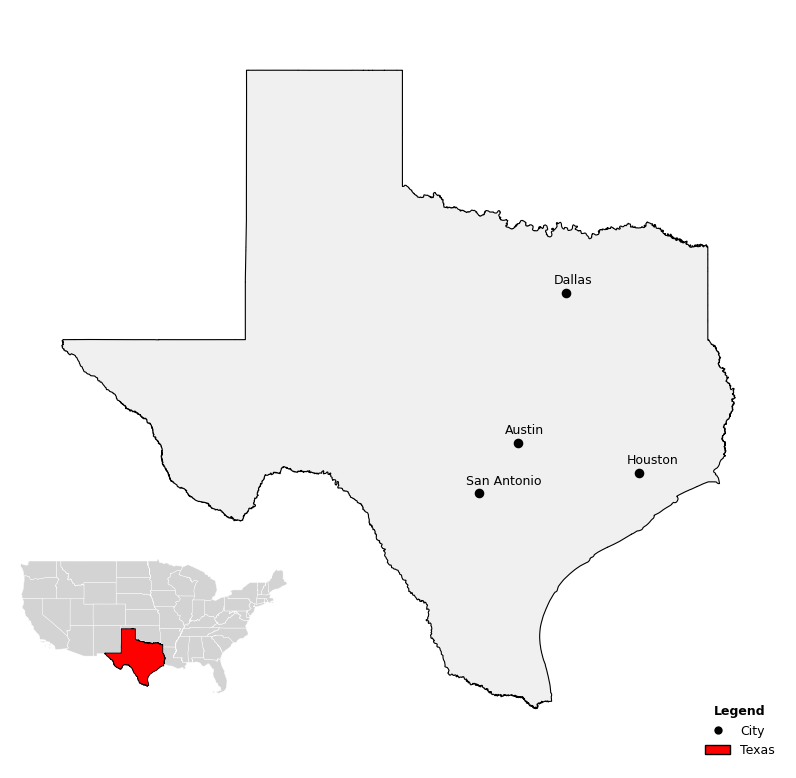

In [ ]:
# Study area 1

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# path (this is a national states file, so you can reuse it)
US_STATES_FP = r"E:\wur_mgi-thesis_method_outlier-analysis\inputs\SC\tl_2025_us_state\tl_2025_us_state.shp"


# Load data
us_states = gpd.read_file(US_STATES_FP, engine="pyogrio")

tx = us_states[us_states["NAME"].str.upper() == "TEXAS"]


# Cities (lon, lat) – edit these to match your thesis text if needed
cities = gpd.GeoDataFrame(
    {
        "city": ["Houston", "Dallas", "San Antonio", "Austin"],
        "geometry": [
            Point(-95.3698, 29.7604),  # Houston
            Point(-96.7970, 32.7767),  # Dallas
            Point(-98.4936, 29.4241),  # San Antonio
            Point(-97.7431, 30.2672),  # Austin
        ],
    },
    crs="EPSG:4326",
)

# Ensure CRS matches
if us_states.crs is not None and cities.crs != us_states.crs:
    cities = cities.to_crs(us_states.crs)

# plot
fig, ax = plt.subplots(figsize=(8, 8))

# Main map
tx.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="black",
    linewidth=0.8,
    zorder=1,
)

# City dots
cities.plot(
    ax=ax,
    color="black",
    markersize=35,
    zorder=3,
)

# City labels 
for x, y, label in zip(cities.geometry.x, cities.geometry.y, cities["city"]):
    ax.text(
        x - 0.25,
        y + 0.10,
        label,
        fontsize=9,
        ha="left",
        va="bottom",
    )

# Set tight extent around Texas, remove axis
minx, miny, maxx, maxy = tx.total_bounds
ax.set_xlim(minx - 1.0, maxx + 1.0)
ax.set_ylim(miny - 1.0, maxy + 1.0)

ax.axis("off")

# Inset
axins = inset_axes(
    ax,
    width="35%",
    height="35%",
    loc="lower left",
    borderpad=1,
)

us_states.plot(
    ax=axins,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.3,
)

tx.plot(
    ax=axins,
    color="red",
    edgecolor="black",
    linewidth=0.6,
)

# Legend 
city_handle = Line2D(
    [0], [0],
    marker="o",
    linestyle="None",
    markerfacecolor="black",
    markeredgecolor="none",
    markersize=6,
)

state_handle = Patch(
    facecolor="red",
    edgecolor="black",
)

leg = ax.legend(
    handles=[city_handle, state_handle],
    labels=["City", "Texas"],
    title="Legend",
    loc="lower right",
    frameon=False,
    fontsize=9,
)

leg.get_title().set_fontsize(9)
leg.get_title().set_fontweight("bold")

# Continental US extent
axins.set_xlim(-125, -66)
axins.set_ylim(24, 50)
axins.axis("off")

plt.tight_layout()
plt.show()

# To do: Michigan looks totally messed up, fix by removing lake michigan, huron & superior. Minor issue is chesapeake with virginia and maryland, less obvious though. Get better shapefile

c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\OneDrive - Wageningen University & Research\WUR\2024-2025\GRS-80436_MScThesisGIRS\4.analysis\4c.spatial_data_analysis\gerrychain\venv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
c:\Users\kubak\One

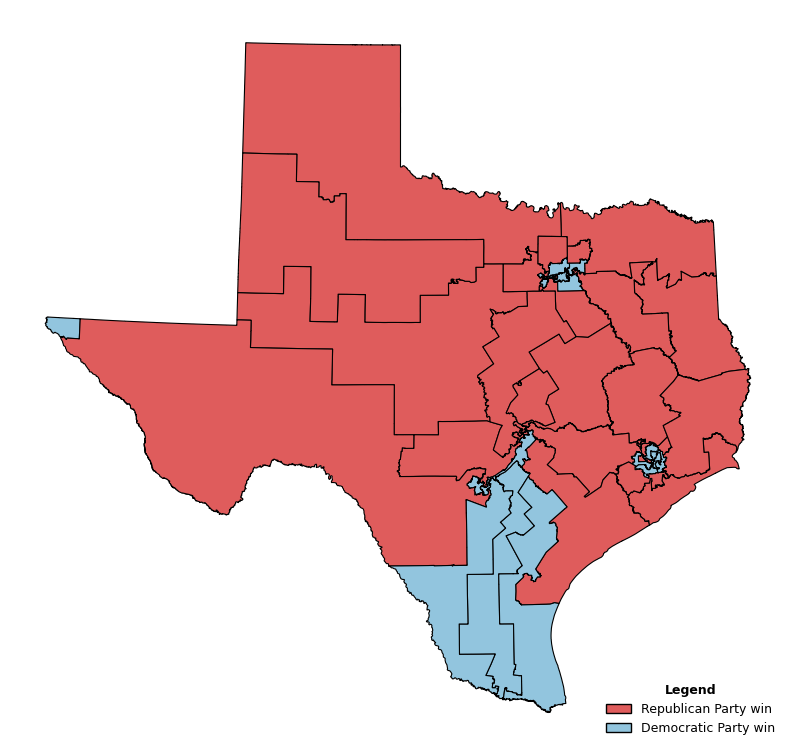

In [ ]:
# study area 2: winners past election

import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# In
VEST_FP = r"./inputs/TX/tx_vest_20/tx_vest_20.shp"
DIST_FP = r"E:\wur_mgi-thesis_method_outlier-analysis\inputs\TX\tx_cong_2012_to_2021\tx_cong_2012_to_2021.shp"
TARGET_PLAN = "PLANC2308"

DEM_COLOR = "#92c5de"
REP_COLOR = "#df5c5c"

# Load
vest = gpd.read_file(VEST_FP, engine="pyogrio")
dists_all = gpd.read_file(DIST_FP, engine="pyogrio")

if vest.crs is None:
    vest = vest.set_crs("EPSG:4326")
if dists_all.crs is None:
    dists_all = dists_all.set_crs("EPSG:4326")
if vest.crs != dists_all.crs:
    vest = vest.to_crs(dists_all.crs)

# Filter districts 
dists = dists_all.copy()
plan_col_candidates = [c for c in dists.columns if re.search(r"(?i)plan|planc|plann?ame|planid", c)]
plan_col = plan_col_candidates[0] if plan_col_candidates else None

if plan_col is not None:
    tmp = dists[plan_col].astype(str)
    if tmp.str.contains(TARGET_PLAN, case=False, na=False).any():
        dists = dists[tmp.str.contains(TARGET_PLAN, case=False, na=False)].copy()

# District ID
for c in ["District", "DISTRICT", "USCD", "CD", "CONG_DIST", "DIST", "DistrictID"]:
    if c in dists.columns:
        DIST_COL = c
        break
else:
    raise ValueError(f"Could not find a district ID column. District columns: {list(dists.columns)}")

dists = dists[[DIST_COL, "geometry"]].copy()


# Votes: include D/R only
PRES20D_raw = "G20PREDBID"
PRES20R_raw = "G20PRERTRU"
assert PRES20D_raw in vest.columns and PRES20R_raw in vest.columns, "Update PRES20 mapping to your VEST columns."

# other presidential candidate columns, excluding totals/pct/share columns
pres_cols = [c for c in vest.columns if re.match(r"(?i)^G20PRE", str(c))]
other_cols = [
    c for c in pres_cols
    if c not in {PRES20D_raw, PRES20R_raw}
    and not re.search(r"(?i)TOT|TOTAL|PCT|SHARE", str(c))
]

for c in [PRES20D_raw, PRES20R_raw, *other_cols]:
    vest[c] = pd.to_numeric(vest[c], errors="coerce").fillna(0.0)

vest["VOTE_D"] = vest[PRES20D_raw]
vest["VOTE_R"] = vest[PRES20R_raw]
vest["VOTE_OTH"] = vest[other_cols].sum(axis=1) if len(other_cols) else 0.0
vest["VOTE_TOT"] = vest["VOTE_D"] + vest["VOTE_R"] + vest["VOTE_OTH"]

vest = vest[vest["VOTE_TOT"] > 0].copy()


# area-weighted allocation via intersection
# Use a projected CRS for area calculations
if vest.crs.is_geographic:
    # NAD83 / Conus Albers Equal Area (good for US-wide area weighting)
    vest_m = vest.to_crs("EPSG:5070")
    dists_m = dists.to_crs("EPSG:5070")
else:
    vest_m, dists_m = vest, dists

vest_m = vest_m[["VOTE_D", "VOTE_R", "VOTE_OTH", "VOTE_TOT", "geometry"]].copy()
vest_m["prec_area"] = vest_m.geometry.area

# Intersection: precinct pieces inside districts
pieces = gpd.overlay(
    vest_m,
    dists_m,
    how="intersection",
    keep_geom_type=False,
)

pieces["piece_area"] = pieces.geometry.area
pieces["w"] = (pieces["piece_area"] / pieces["prec_area"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Allocate votes proportionally
for col in ["VOTE_D", "VOTE_R", "VOTE_OTH", "VOTE_TOT"]:
    pieces[col] = pieces[col] * pieces["w"]

# Aggregate to districts
agg = (
    pieces.groupby(DIST_COL)[["VOTE_D", "VOTE_R", "VOTE_OTH", "VOTE_TOT"]]
          .sum()
          .reset_index()
)

# Winner still D vs R, no other
agg["WINNER"] = np.where(agg["VOTE_D"] > agg["VOTE_R"], "D", "R")

# Margin in percentage points
two_party = (agg["VOTE_D"] + agg["VOTE_R"]).replace(0, np.nan)
agg["MARGIN"] = (abs(agg["VOTE_D"] - agg["VOTE_R"]) / two_party) * 100

# Merge back to district geometry
d_map = dists_m.merge(agg, on=DIST_COL, how="left").to_crs(dists.crs)

# Plot 
fig, ax = plt.subplots(figsize=(8, 8))
colors = d_map["WINNER"].map({"D": DEM_COLOR, "R": REP_COLOR})
d_map.plot(ax=ax, color=colors, edgecolor="black", linewidth=0.8)

ax.axis("off")

legend_handles = [
    Patch(facecolor=REP_COLOR, edgecolor="black", label="Republican Party win"),
    Patch(facecolor=DEM_COLOR, edgecolor="black", label="Democratic Party win"),
]
leg = ax.legend(handles=legend_handles, title="Legend", loc="lower right", frameon=False, fontsize=9)
leg.get_title().set_fontsize(9)
leg.get_title().set_fontweight("bold")

plt.tight_layout()
plt.show()
